# Pronóstico de Bitcoin con Prophet

### Introducción práctica al *forecasting* de series de tiempo con Python

---

## Propósito del notebook

Este laboratorio es una **introducción práctica al pronóstico de series de tiempo** usando la
librería **Prophet** (desarrollada originalmente por Meta/Facebook) aplicada al **precio diario de
cierre de Bitcoin (`BTC-USD`)**.

El recorrido no consiste solo en ejecutar celdas: en cada etapa nos preguntamos *qué* estamos
haciendo, *por qué*, *qué supuesto* estamos asumiendo, *cómo se interpreta* el resultado y *qué
decisión* podemos tomar con él.

## Objetivos de aprendizaje

Al terminar este notebook deberías ser capaz de:

1. Explicar **qué problema resuelve** Prophet y en qué se diferencia de describir una serie.
2. **Preparar datos temporales** con el formato que Prophet exige (`ds`, `y`).
3. **Explorar** una serie temporal y evaluar su calidad (faltantes, duplicados, orden, frecuencia).
4. Separar **entrenamiento y prueba respetando el orden cronológico**.
5. **Ajustar** un modelo Prophet y entender qué ocurre durante el entrenamiento.
6. **Generar pronósticos** con su intervalo de incertidumbre.
7. **Interpretar** la tendencia y la estacionalidad estimadas.
8. Identificar **puntos de cambio** (*changepoints*) y el papel de `changepoint_prior_scale`.
9. **Evaluar** el pronóstico con MAE, RMSE, MAPE y sMAPE, y compararlo con un **modelo ingenuo**.
10. Ejecutar una **validación cruzada temporal** (*rolling origin*) e interpretar sus métricas.
11. Discutir de forma crítica las **limitaciones** del modelo.

## Conocimientos previos

- Python básico: variables, funciones, `import`.
- `pandas` a nivel introductorio: `DataFrame`, filtros, `merge`.
- Nociones de estadística descriptiva (media, desviación, error).
- No se requiere experiencia previa con Prophet.

## Herramientas

| Herramienta | Para qué la usamos |
|---|---|
| `pandas`, `numpy` | Manipulación de datos y cálculo de métricas |
| `yfinance` | Descarga del histórico de precios de Bitcoin |
| `matplotlib` | Gráficas estáticas y salidas propias de Prophet |
| `plotly` | Gráficas interactivas (zoom sobre la serie) |
| `prophet` | Modelo de pronóstico, diagnóstico y validación cruzada |

## Cómo está organizado

Cada bloque importante sigue, cuando tiene sentido, esta secuencia:

> **¿Qué queremos hacer?** → **¿Por qué lo hacemos?** → **Código** → **Resultado** →
> **¿Cómo lo interpretamos?** → **Idea clave**

---

# 1. La pregunta que vamos a responder

> ### ¿Podemos usar el comportamiento histórico del precio de Bitcoin para construir un modelo que pronostique su precio en los próximos días?

Esta pregunta es deliberadamente ambiciosa. Durante el notebook la iremos afinando hasta convertirla
en algo medible:

> *Ajustando Prophet con datos de Bitcoin hasta una fecha de corte, ¿qué tan lejos quedan sus
> pronósticos de los precios realmente observados en los 60 días siguientes, y mejora eso a una
> predicción trivial?*

> ### ⚠️ Advertencia importante
>
> El objetivo de este notebook es **pedagógico**: aprender el flujo completo de trabajo de un
> problema de *forecasting*. **Nada de lo que aparece aquí es asesoría financiera**, y el hecho de
> que apliquemos Prophet a Bitcoin **no implica que Prophet sea un modelo adecuado para invertir**.
>
> De hecho, uno de los aprendizajes más valiosos del laboratorio será entender **por qué** los
> precios de activos especulativos son un caso especialmente difícil (y en buena medida
> impredecible) para este tipo de modelos. Usamos Bitcoin porque es una serie pública, larga, sin
> huecos de fin de semana y con cambios de tendencia muy visibles: es un excelente material
> didáctico, no una recomendación.

---

# 2. ¿Qué es un pronóstico de series de tiempo?

Una **serie de tiempo** es una secuencia de observaciones de una misma variable, ordenadas en el
tiempo y normalmente espaciadas de forma regular: el precio diario de Bitcoin, la temperatura
horaria de Bogotá, las ventas mensuales de una tienda.

Lo que hace especial a una serie de tiempo es que **el orden importa**. Si barajamos las filas de
una tabla de clientes no perdemos nada; si barajamos las filas de una serie de tiempo, destruimos
justo la información que queremos aprovechar.

### Descripción, predicción y *forecasting*

| Tarea | Pregunta que responde | Ejemplo con Bitcoin |
|---|---|---|
| **Descripción** | ¿Qué pasó? | "El precio subió durante 2023" |
| **Predicción** (general) | Dadas unas variables, ¿cuál es el valor de otra? | "Dado el volumen y la volatilidad de hoy, ¿cuál es el precio de hoy?" |
| ***Forecasting*** | ¿Qué pasará **después** del último dato que tengo? | "¿Cuál será el precio dentro de 30 días?" |

El *forecasting* es un caso particular de predicción en el que **extrapolamos hacia el futuro**
usando solamente información del pasado. Esa restricción —"solo puedo usar lo que ya ocurrió"— es la
que gobierna todas las decisiones metodológicas del notebook.

### Los componentes clásicos de una serie

Una forma útil (aunque simplificada) de pensar una serie es imaginarla como la suma de varias piezas:

- **Tendencia** *(trend)*: el movimiento de fondo, de largo plazo. Ejemplo: la población de una
  ciudad que crece década tras década.
- **Estacionalidad** *(seasonality)*: patrones que se repiten con un **periodo fijo y conocido**.
  Ejemplo: las ventas de helado suben cada verano; el tráfico de una web baja cada domingo.
- **Ciclos**: oscilaciones de duración **variable y no fija**, típicamente más largas que un año.
  Ejemplo: los ciclos económicos de expansión y recesión. A diferencia de la estacionalidad, no
  sabemos de antemano cuánto durarán.
- **Ruido** *(noise)*: la parte irregular que no explicamos con nada de lo anterior.
- **Cambio estructural**: un momento en que las reglas del juego cambian y la serie se comporta
  distinto a partir de ahí. Ejemplo: el uso del transporte público antes y después de marzo de 2020.

> ### 💡 Idea clave
> Un modelo de *forecasting* es esencialmente una **hipótesis sobre qué parte del pasado se va a
> repetir**. Si esa hipótesis es razonable, el modelo funciona; si el futuro rompe el patrón, no hay
> algoritmo que lo salve.

---

# 3. ¿Qué es Prophet y cómo funciona?

Prophet es una librería de pronóstico de series de tiempo **univariadas** (una sola variable en el
tiempo). Su idea central es descomponer la serie en piezas interpretables y sumarlas. Formalmente,
Prophet es un **modelo aditivo** (un GAM, *Generalized Additive Model*) donde el tiempo es la única
variable explicativa:

$$
y(t) = g(t) + s(t) + h(t) + \epsilon_t
$$

| Término | Nombre | Qué representa | En nuestro caso |
|---|---|---|---|
| $g(t)$ | **Tendencia** | Cambios no periódicos de largo plazo. Puede ser lineal (a tramos) o logística (con saturación). | El movimiento de fondo del precio de BTC |
| $s(t)$ | **Estacionalidad** | Patrones periódicos (semanal, anual...), modelados con series de Fourier. | ¿Hay días de la semana sistemáticamente más altos? |
| $h(t)$ | **Días especiales** | Feriados o eventos puntuales con impacto irregular. | No los usaremos: Bitcoin cotiza los 365 días |
| $\epsilon_t$ | **Error** | Todo lo que el modelo **no** explica. Se asume ruido no correlacionado. | Volatilidad, noticias, shocks del mercado |

### La intuición

Imagina que dibujas la serie en papel y se la explicas a alguien así: *"en el fondo va subiendo
(tendencia), encima de eso los lunes suele estar un poco más bajo (estacionalidad semanal), en
Navidad se dispara (feriados), y el resto es azar (error)"*. Prophet hace exactamente eso, pero
estimando cada pieza a partir de los datos. Por eso es tan didáctico: **el modelo se puede dibujar y
explicar componente por componente**, algo que no ocurre con una red neuronal.

Dos detalles importantes que veremos más adelante:

- La tendencia $g(t)$ es **lineal a tramos**: Prophet propone muchos posibles **puntos de cambio**
  (*changepoints*) donde la pendiente puede quebrarse, y penaliza que se usen demasiados.
- La estacionalidad $s(t)$ se representa con **series de Fourier**, lo que le permite tomar formas
  suaves y no solo escalones.

### ¿Cuándo puede ser útil Prophet?

- Series **diarias, semanales u horarias** con historia suficiente (idealmente más de un año).
- Cuando hay **varias estacionalidades a la vez** (por ejemplo, semanal + anual).
- Cuando la **tendencia cambia** varias veces a lo largo del histórico.
- Cuando hay **datos faltantes** o mediciones irregulares: Prophet no exige una rejilla perfecta.
- Cuando existen **eventos especiales conocidos** (feriados, campañas, lanzamientos) que podemos
  declarar explícitamente.
- Cuando se necesita un modelo **rápido de ajustar e interpretable**, que un equipo no especialista
  pueda auditar y corregir a mano.

### ¿Cuándo Prophet puede **no** ser la mejor opción?

- Cuando la serie es **altamente volátil y sin patrón estable**, como los precios financieros: buena
  parte del movimiento diario se comporta como un **paseo aleatorio**, y no hay estacionalidad que
  capturar.
- Cuando el valor futuro depende de **otras variables** más que del calendario (demanda que responde
  al precio, a la competencia, al clima). Prophet admite regresores externos, pero si el problema es
  fundamentalmente multivariado, hay herramientas mejores.
- Cuando importa modelar la **autocorrelación de los errores** o la **varianza cambiante**
  (volatilidad agrupada): ahí ARIMA/SARIMA o modelos GARCH son más apropiados.
- Cuando se necesita capturar **shocks nunca vistos**: Prophet extrapola los patrones del pasado y,
  por construcción, no puede anticipar lo que nunca ocurrió.
- En **horizontes muy largos**, donde la extrapolación de la tendencia se vuelve poco creíble.

> ### 💡 Idea clave
> Prophet es un modelo **descriptivo del calendario**: explica la serie en función del tiempo, no de
> sus causas. Es excelente para series con ritmo humano (ventas, tráfico, demanda) y débil para
> series dominadas por el azar (precios de activos).

---

# 4. Preparación del entorno

### 🎯 ¿Qué queremos hacer?
Asegurarnos de que las librerías necesarias estén disponibles **antes** de empezar, y dejar
constancia de las versiones usadas.

### 🧠 ¿Por qué lo hacemos?
Prophet no es una librería de Python "pura": por debajo usa **Stan** (a través de `cmdstanpy`), un
motor de inferencia bayesiana escrito en C++. Esa dependencia es la causa de casi todos los
problemas de instalación. Registrar las versiones hace que el notebook sea **reproducible** y
facilita pedir ayuda cuando algo falla.

La siguiente celda está **comentada a propósito**: si ya tienes las librerías instaladas, reinstalar
en cada ejecución es lento e innecesario (y en algunos entornos puede romper la instalación
existente). Descoméntala solo la primera vez o si la celda de diagnóstico falla.

In [1]:
# Ejecuta esta celda SOLO si falta alguna librería (por ejemplo, la primera vez en Google Colab).
# En Colab suele ser necesario; en una instalación local de Anaconda normalmente no.
#
# IMPORTANTE: si la ejecutas, REINICIA EL KERNEL antes de seguir (Kernel -> Restart) y
# vuelve a empezar desde la primera celda. Instalar Prophet dentro de un kernel que ya lo
# tenía cargado deja el paquete a medio reemplazar y provoca el error 'stan_backend' que
# se explica más abajo.

# %pip install -q yfinance prophet plotly

### Diagnóstico del entorno

Si la siguiente celda imprime las versiones sin errores, el entorno está listo.

In [2]:
import sys

import prophet
import cmdstanpy
import pandas as pd
import numpy as np

print("Python   :", sys.version.split()[0])
print("Prophet  :", prophet.__version__)
print("CmdStanPy:", cmdstanpy.__version__)
print("Pandas   :", pd.__version__)
print("NumPy    :", np.__version__)
print("\nIntérprete en uso:", sys.executable)

Python   : 3.13.12
Prophet  : 1.3.0
CmdStanPy: 1.3.0
Pandas   : 3.0.2
NumPy    : 2.4.4

Intérprete en uso: c:\Users\wsand\AppData\Local\Programs\Python\Python313\python.exe


### Comprobación del motor de Stan

Las versiones pueden imprimirse sin problema y aun así fallar el modelo, porque Prophet necesita
además su **motor de Stan compilado**. Merece la pena comprobarlo ahora —cuesta un segundo— en lugar
de descubrirlo veinte celdas más abajo.

Hay un motivo concreto para hacerlo. Cuando Prophet construye un modelo llama a
`_load_stan_backend()`, que recorre los backends disponibles dentro de un `try/except` que
**descarta la excepción original**. Si ninguno carga, el atributo `stan_backend` nunca se asigna y
lo que ves es este mensaje desconcertante:

```text
AttributeError: 'Prophet' object has no attribute 'stan_backend'
```

Ese error **no dice cuál fue el problema real**, y además aparece al crear o ajustar el modelo, lo
que hace pensar que la culpa es de tus datos o de `df_train`. No lo es. La celda siguiente prueba
cada backend por separado y **muestra la excepción auténtica** que Prophet se guarda.

In [3]:
from pathlib import Path

from prophet import Prophet
from prophet.models import StanBackendEnum


def comprobar_backend_stan(verbose=True):
    """Verifica que el motor de Stan de Prophet se pueda cargar.

    Prophet oculta la excepción real cuando falla la carga del backend; esta función la
    saca a la luz. Devuelve True si el entorno está listo para ajustar modelos.
    """
    carpeta = Path(prophet.__file__).parent
    binario = carpeta / "stan_model" / "prophet_model.bin"

    if verbose:
        print(f"Instalación de Prophet   : {carpeta}")
        print(f"Modelo compilado de Stan : "
              f"{'encontrado' if binario.exists() else 'NO ENCONTRADO'}")

    fallos = {}
    for backend in StanBackendEnum:
        try:
            StanBackendEnum.get_backend_class(backend.name)()
        except Exception as error:
            fallos[backend.name] = f"{type(error).__name__}: {error}"
        else:
            if verbose:
                print(f"Backend '{backend.name}'    : OK")
            Prophet()   # prueba final: construir un modelo vacío
            if verbose:
                print("\n✅ Entorno listo: Prophet() se construye correctamente.")
            return True

    print("\n❌ Ningún backend de Stan pudo cargarse. Causa real de cada intento:")
    for nombre, motivo in fallos.items():
        print(f"   - {nombre}: {motivo}")
    print("\nEsto NO es un problema de tus datos. Ve a la sección "
          "'Solución de problemas de instalación', justo debajo.")
    return False


entorno_listo = comprobar_backend_stan()

Instalación de Prophet   : c:\Users\wsand\AppData\Local\Programs\Python\Python313\Lib\site-packages\prophet
Modelo compilado de Stan : encontrado
Backend 'CMDSTANPY'    : OK

✅ Entorno listo: Prophet() se construye correctamente.


---

# 5. Importación de librerías y configuración

### 🎯 ¿Qué queremos hacer?
Cargar en un solo lugar todo lo que usaremos, agrupado por función, y fijar algunas opciones de
presentación.

### 🧠 ¿Por qué lo hacemos?
Concentrar los `import` al inicio evita importaciones duplicadas y permite a cualquier lector saber
de un vistazo de qué depende el notebook. Esta es la **única** celda de importaciones: a partir de
aquí, cada celda depende solo de las anteriores.

In [4]:
# --- Manipulación de datos -------------------------------------------------
import logging
from pathlib import Path

import numpy as np
import pandas as pd

# --- Datos financieros -----------------------------------------------------
import yfinance as yf

# --- Motor de inferencia (solo para configurar su registro de mensajes) ----
import cmdstanpy

# --- Visualización ---------------------------------------------------------
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# --- Prophet ---------------------------------------------------------------
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot, plot_cross_validation_metric
from prophet.diagnostics import cross_validation, performance_metrics

# --- Utilidades del notebook ----------------------------------------------
from IPython.display import Markdown, display

# Silenciamos los mensajes informativos del motor Stan para no saturar la salida.
# cmdstanpy configura su logger de forma perezosa (la primera vez que se ajusta un modelo)
# y lo deja en nivel DEBUG; por eso lo forzamos a inicializarse antes de bajarle el nivel.
cmdstanpy.utils.get_logger()
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

# Opciones de presentación
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Prophet estima por optimización determinista (MAP), así que el ajuste es reproducible.
# Fijamos además la semilla de NumPy para cualquier cálculo aleatorio auxiliar.
np.random.seed(42)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


---

# 6. Descarga de los datos

### 🎯 ¿Qué queremos hacer?
Obtener el histórico diario de precios de **Bitcoin** (`BTC-USD`) entre enero de 2018 y agosto de
2024.

### 🧠 ¿Por qué lo hacemos?
Necesitamos una serie **suficientemente larga** para que el modelo pueda estimar tendencia y
estacionalidad anual. Con menos de dos años completos, Prophet desactiva automáticamente la
estacionalidad anual porque no tiene con qué estimarla. Nuestra ventana cubre unos **6,7 años**, con
un mercado alcista (2020-2021), una caída profunda (2022) y una recuperación (2023-2024): un
escenario ideal para estudiar **cambios de tendencia**.

### ¿Por qué un ticker de criptomoneda y no una acción?
`BTC-USD` cotiza **los 365 días del año**. Una acción como `AAPL` solo cotiza en días hábiles, lo que
deja huecos de fin de semana y feriados; eso complica el cálculo de la estacionalidad semanal y el
alineamiento entre el horizonte de pronóstico y las fechas reales. Con Bitcoin, un día de calendario
equivale a una observación, y eso simplifica todo el análisis.

### Una nota sobre `yfinance`
Las versiones recientes de `yfinance` devuelven un **`MultiIndex` de columnas** con dos niveles
(`Price`, `Ticker`) incluso cuando se pide un solo ticker, y el nombre de la columna de fecha puede
variar (`Date` o `Datetime`). La función siguiente **normaliza** esas diferencias para que el resto
del notebook funcione sin importar la versión instalada.

In [5]:
# --- Parámetros del experimento (cámbialos y vuelve a ejecutar el notebook) ---
TICKER = "BTC-USD"
FECHA_INICIO = "2018-01-01"
FECHA_FIN = "2026-08-30"   # fija, para que los resultados del notebook sean reproducibles

# Guardamos una copia local: si algún día la API no responde, el notebook sigue funcionando.
RUTA_CACHE = Path(f"datos_{TICKER.replace('-', '_').lower()}.csv")


def descargar_precios(ticker: str, inicio: str, fin: str) -> pd.DataFrame:
    """Descarga precios diarios y normaliza la salida entre versiones de yfinance.

    Devuelve un DataFrame con columnas Date, Open, High, Low, Close, Adj Close, Volume.
    """
    datos = yf.download(
        ticker,
        start=inicio,
        end=fin,
        interval="1d",
        auto_adjust=False,   # conservamos 'Close' y 'Adj Close' por separado
        progress=False,
    )

    if datos is None or len(datos) == 0:
        raise ValueError(f"La descarga de {ticker} no devolvió datos.")

    # yfinance >= 0.2.51 devuelve columnas MultiIndex (Price, Ticker) aun con un solo ticker.
    if isinstance(datos.columns, pd.MultiIndex):
        if ticker in set(datos.columns.get_level_values(-1)):
            datos = datos.xs(ticker, axis=1, level=-1)
        else:
            datos = datos.droplevel(-1, axis=1)

    datos.columns.name = None
    datos = datos.reset_index()

    # La columna de fecha puede llamarse 'Date' o 'Datetime' según el intervalo pedido.
    datos = datos.rename(columns={datos.columns[0]: "Date"})
    datos["Date"] = pd.to_datetime(datos["Date"])

    # Si la fecha trae zona horaria, la quitamos: Prophet exige datetime sin tz.
    if isinstance(datos["Date"].dtype, pd.DatetimeTZDtype):
        datos["Date"] = datos["Date"].dt.tz_localize(None)

    return datos


try:
    df = descargar_precios(TICKER, FECHA_INICIO, FECHA_FIN)
    df.to_csv(RUTA_CACHE, index=False)
    print(f"Datos descargados de Yahoo Finance y guardados en '{RUTA_CACHE}'.")
except Exception as error:
    print(f"No se pudo descargar ({type(error).__name__}: {error}). Intentando copia local...")
    df = pd.read_csv(RUTA_CACHE, parse_dates=["Date"])
    print(f"Datos leídos desde la copia local '{RUTA_CACHE}'.")

print(f"\n{len(df)} observaciones diarias de {TICKER}")
print(f"desde {df['Date'].min():%Y-%m-%d} hasta {df['Date'].max():%Y-%m-%d}")
df.head()

Datos descargados de Yahoo Finance y guardados en 'datos_btc_usd.csv'.

3163 observaciones diarias de BTC-USD
desde 2018-01-01 hasta 2026-08-29


,Date,Adj Close,Close,High,Low,Open,Volume
0,2018-01-01,"13,657.20","13,657.20","14,112.20","13,154.70","14,112.20",10291200000
1,2018-01-02,"14,982.10","14,982.10","15,444.60","13,163.60","13,625.00",16846600192
2,2018-01-03,"15,201.00","15,201.00","15,572.80","14,844.50","14,978.20",16871900160
3,2018-01-04,"15,599.20","15,599.20","15,739.70","14,522.20","15,270.70",21783199744
4,2018-01-05,"17,429.50","17,429.50","17,705.20","15,202.80","15,477.20",23840899072


### 🔎 ¿Qué significa cada columna?

Cada fila resume **un día de negociación** del activo:

| Columna | Significado | Por qué importa |
|---|---|---|
| **`Date`** | Día de calendario de la observación | Es nuestro eje temporal |
| **`Open`** | Precio de la **primera** operación del día | Punto de partida de la jornada |
| **`High`** | Precio **máximo** alcanzado en el día | Mide el techo intradía |
| **`Low`** | Precio **mínimo** alcanzado en el día | Mide el piso intradía; junto con `High` describe la volatilidad del día |
| **`Close`** | Precio de la **última** operación del día | Valor de referencia del día: **será nuestra variable objetivo** |
| **`Adj Close`** | Cierre ajustado por dividendos y *splits* | En criptomonedas **coincide con `Close`**, porque no hay dividendos ni divisiones |
| **`Volume`** | Cantidad negociada durante el día | Indica cuánta actividad hubo; un movimiento con mucho volumen suele considerarse más "firme" |

**¿Por qué elegimos `Close` como variable a pronosticar?** Porque es el precio de cierre de la
jornada, el que se usa convencionalmente como resumen del día y el que aparece en la mayoría de los
análisis. `High` y `Low` describen el *rango* del día, no su nivel, y en un mercado que opera 24
horas el `Open` de un día es casi idéntico al `Close` del anterior.

> ### 💡 Idea clave
> Prophet es un modelo **univariado**: solo usará `Date` y `Close`. Toda la información de `Volume`,
> `High` y `Low` queda fuera del modelo. Vale la pena volver a esto al final: ¿estamos
> desaprovechando información útil?

---

# 7. Exploración y calidad de los datos

### 🎯 ¿Qué queremos hacer?
Antes de modelar, auditar los datos: tamaño, tipos, valores faltantes, duplicados, orden cronológico
y frecuencia.

### 🧠 ¿Por qué lo hacemos?
Un modelo no puede arreglar datos malos. En series de tiempo hay cuatro problemas que arruinan
silenciosamente un análisis y que **no** producen ningún error de Python:

1. **Fechas duplicadas**: la misma fecha aparece dos veces y el modelo ve dos valores para el mismo
   instante.
2. **Fechas desordenadas**: el "futuro" aparece antes que el "pasado" en la tabla.
3. **Huecos en el calendario**: días sin observación, que rompen el supuesto de frecuencia regular.
4. **Valores faltantes o imposibles**: precios nulos, ceros o negativos.

Los detectamos ahora, no después de ver un pronóstico extraño.

In [6]:
print("Dimensiones (filas, columnas):", df.shape)
print("\n--- Primeras filas ---")
display(df.head())
print("--- Últimas filas ---")
display(df.tail())

Dimensiones (filas, columnas): (3163, 7)

--- Primeras filas ---


,Date,Adj Close,Close,High,Low,Open,Volume
0,2018-01-01,"13,657.20","13,657.20","14,112.20","13,154.70","14,112.20",10291200000
1,2018-01-02,"14,982.10","14,982.10","15,444.60","13,163.60","13,625.00",16846600192
2,2018-01-03,"15,201.00","15,201.00","15,572.80","14,844.50","14,978.20",16871900160
3,2018-01-04,"15,599.20","15,599.20","15,739.70","14,522.20","15,270.70",21783199744
4,2018-01-05,"17,429.50","17,429.50","17,705.20","15,202.80","15,477.20",23840899072


--- Últimas filas ---


,Date,Adj Close,Close,High,Low,Open,Volume
3158,2026-08-25,"78,564.98","78,564.98","81,235.03","77,870.62","78,960.09",46728068401
3159,2026-08-26,"79,027.42","79,027.42","79,240.50","77,639.84","78,538.59",29329039002
3160,2026-08-27,"80,257.54","80,257.54","80,806.56","78,591.10","79,037.92",34033075972
3161,2026-08-28,"77,830.29","77,830.29","81,346.95","76,909.35","80,264.65",39362871737
3162,2026-08-29,"78,245.81","78,245.81","78,327.95","77,381.90","77,830.89",14053131399


In [7]:
print("--- Tipos de dato y memoria ---")
df.info()

--- Tipos de dato y memoria ---
<class 'pandas.DataFrame'>
RangeIndex: 3163 entries, 0 to 3162
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   Date       3163 non-null   datetime64[s]
 1   Adj Close  3163 non-null   float64      
 2   Close      3163 non-null   float64      
 3   High       3163 non-null   float64      
 4   Low        3163 non-null   float64      
 5   Open       3163 non-null   float64      
 6   Volume     3163 non-null   int64        
dtypes: datetime64[s](1), float64(5), int64(1)
memory usage: 173.1 KB


In [8]:
print("--- Estadísticos descriptivos ---")
df.describe().T

--- Estadísticos descriptivos ---


,count,mean,min,25%,50%,75%,max,std
Date,3163,2022-05-01 00:00:00,2018-01-01 00:00:00,2020-03-01 12:00:00,2022-05-01 00:00:00,2024-06-29 12:00:00,2026-08-29 00:00:00,NaN
Adj Close,"3,163.00","39,929.42","3,236.76","9,857.38","29,918.41","63,328.24","124,752.53","32,412.24"
Close,"3,163.00","39,929.42","3,236.76","9,857.38","29,918.41","63,328.24","124,752.53","32,412.24"
High,"3,163.00","40,680.93","3,275.38","10,080.04","30,437.56","64,337.45","126,198.07","32,922.91"
Low,"3,163.00","39,090.13","3,191.30","9,623.34","29,376.80","62,229.79","123,196.05","31,857.54"
Open,"3,163.00","39,910.40","3,236.27","9,850.60","29,910.28","63,310.18","124,752.14","32,408.79"
Volume,"3,163.00","30,623,900,998.79","2,923,670,016.00","15,868,028,487.00","26,688,438,115.00","40,201,769,454.00","350,967,941,479.00","21,646,180,668.34"


### Comprobaciones específicas de series de tiempo

Las celdas anteriores son el diagnóstico estándar de cualquier tabla. Las siguientes son las que
importan **porque esto es una serie de tiempo**.

In [9]:
# 1) Valores faltantes por columna
faltantes = df.isna().sum()

# 2) Filas completamente duplicadas
filas_duplicadas = df.duplicated().sum()

# 3) Fechas duplicadas (más grave: dos valores para el mismo día)
fechas_duplicadas = df["Date"].duplicated().sum()

# 4) ¿Están las fechas en orden cronológico ascendente?
ordenado = df["Date"].is_monotonic_increasing

# 5) Frecuencia: diferencia entre fechas consecutivas
diferencias = df["Date"].diff().dropna()
conteo_diferencias = diferencias.value_counts()

# 6) Días de calendario sin observación dentro del rango
rango_completo = pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")
dias_faltantes = rango_completo.difference(df["Date"])

print("Valores faltantes por columna:")
print(faltantes.to_string())
print(f"\nFilas duplicadas completas : {filas_duplicadas}")
print(f"Fechas duplicadas          : {fechas_duplicadas}")
print(f"Fechas en orden ascendente : {ordenado}")
print(f"\nSeparación entre observaciones consecutivas:")
print(conteo_diferencias.head().to_string())
print(f"\nDías de calendario sin observación: {len(dias_faltantes)}")
if len(dias_faltantes) > 0:
    print("Ejemplos:", [f"{d:%Y-%m-%d}" for d in dias_faltantes[:10]])

Valores faltantes por columna:
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0

Filas duplicadas completas : 0
Fechas duplicadas          : 0
Fechas en orden ascendente : True

Separación entre observaciones consecutivas:
Date
1 days    3162

Días de calendario sin observación: 0


In [10]:
# 7) Valores no válidos para un precio y detección orientativa de atípicos
no_positivos = int((df["Close"] <= 0).sum())

# Variación porcentual diaria: la forma natural de mirar atípicos en un precio
retorno_diario = df["Close"].pct_change() * 100
extremos = retorno_diario.abs().nlargest(5)

print(f"Precios de cierre menores o iguales a cero: {no_positivos}")
print(f"\nVariación diaria: media = {retorno_diario.mean():.2f} %, "
      f"desviación estándar = {retorno_diario.std():.2f} %")
print("\nLos 5 días con mayor variación absoluta:")
for indice, valor in extremos.items():
    print(f"  {df.loc[indice, 'Date']:%Y-%m-%d}: {retorno_diario[indice]:+.2f} %  "
          f"(cierre {df.loc[indice, 'Close']:,.0f} USD)")

Precios de cierre menores o iguales a cero: 0

Variación diaria: media = 0.11 %, desviación estándar = 3.33 %

Los 5 días con mayor variación absoluta:
  2020-03-12: -37.17 %  (cierre 4,971 USD)
  2021-02-08: +18.75 %  (cierre 46,196 USD)
  2020-03-19: +18.19 %  (cierre 6,191 USD)
  2019-04-02: +17.36 %  (cierre 4,880 USD)
  2018-01-16: -16.85 %  (cierre 11,490 USD)


In [11]:
# Resumen automático del diagnóstico
problemas = []
if faltantes.sum() > 0:
    problemas.append(f"hay {int(faltantes.sum())} valores faltantes")
if fechas_duplicadas > 0:
    problemas.append(f"hay {int(fechas_duplicadas)} fechas duplicadas")
if not ordenado:
    problemas.append("las fechas no están ordenadas cronológicamente")
if len(dias_faltantes) > 0:
    problemas.append(f"faltan {len(dias_faltantes)} días de calendario")
if no_positivos > 0:
    problemas.append(f"hay {no_positivos} precios no positivos")

veredicto = ("**No se detectaron problemas de calidad.** " if not problemas
             else "**Atención:** " + "; ".join(problemas) + ". ")

display(Markdown(f"""
### 🔎 ¿Cómo lo interpretamos?

{veredicto}La serie tiene **{len(df):,} observaciones** que cubren
**{(df['Date'].max() - df['Date'].min()).days:,} días** entre
{df['Date'].min():%d/%m/%Y} y {df['Date'].max():%d/%m/%Y}, con frecuencia **diaria y sin huecos**
(Bitcoin cotiza los 365 días del año, a diferencia de una acción).

El precio de cierre va de **{df['Close'].min():,.0f} USD** a **{df['Close'].max():,.0f} USD**: un
rango de más de **{df['Close'].max() / df['Close'].min():.0f} veces**. Esa amplitud es la primera
señal de que estamos ante una serie difícil.

Sobre los "atípicos": en una serie de precios, un día con una variación de ±15 % **no es un error de
medición** que haya que eliminar, sino información real sobre la volatilidad del activo. Borrarlos
sería ocultar justo lo que hace interesante (y difícil) el problema. Por eso **no eliminamos ningún
dato**: solo dejamos constancia de que existen.
"""))


### 🔎 ¿Cómo lo interpretamos?

**No se detectaron problemas de calidad.** La serie tiene **3,163 observaciones** que cubren
**3,162 días** entre
01/01/2018 y 29/08/2026, con frecuencia **diaria y sin huecos**
(Bitcoin cotiza los 365 días del año, a diferencia de una acción).

El precio de cierre va de **3,237 USD** a **124,753 USD**: un
rango de más de **39 veces**. Esa amplitud es la primera
señal de que estamos ante una serie difícil.

Sobre los "atípicos": en una serie de precios, un día con una variación de ±15 % **no es un error de
medición** que haya que eliminar, sino información real sobre la volatilidad del activo. Borrarlos
sería ocultar justo lo que hace interesante (y difícil) el problema. Por eso **no eliminamos ningún
dato**: solo dejamos constancia de que existen.


---

# 8. Análisis exploratorio

### 🎯 ¿Qué queremos hacer?
Mirar la serie antes de modelarla: forma general, cambios de régimen, volatilidad y actividad.

### 🧠 ¿Por qué lo hacemos?
La elección del modelo debería seguir a la observación, no al revés. De esta exploración saldrán
decisiones concretas: si la tendencia es lineal o necesita quiebres, si hay estacionalidad visible y
si la variabilidad crece con el nivel (lo que inclinaría la balanza hacia una estacionalidad
*multiplicativa*).

## 8.1 Precio histórico de cierre

In [12]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df["Date"], y=df["Close"],
        mode="lines", name="Cierre BTC-USD",
        line=dict(color="#1f77b4", width=1.4),
        hovertemplate="%{x|%d %b %Y}<br>%{y:$,.0f}<extra></extra>",
    )
)
fig.update_layout(
    title=f"Precio de cierre diario de {TICKER} ({FECHA_INICIO} a {FECHA_FIN})",
    xaxis_title="Fecha", yaxis_title="Precio de cierre (USD)",
    template="plotly_white", height=460, hovermode="x unified",
)
fig.show()

In [13]:
# Resumen por año para apoyar la lectura de la gráfica
resumen_anual = (
    df.assign(anio=df["Date"].dt.year)
      .groupby("anio")
      .agg(minimo=("Close", "min"), maximo=("Close", "max"),
           promedio=("Close", "mean"), cierre_anual=("Close", "last"))
)
resumen_anual["variacion_%"] = resumen_anual["cierre_anual"].pct_change() * 100
resumen_anual

,minimo,maximo,promedio,cierre_anual,variacion_%
anio,,,,,
2018,"3,236.76","17,527.00","7,572.30","3,742.70",NaN
2019,"3,399.47","13,016.23","7,395.25","7,193.60",92.20
2020,"4,970.79","29,001.72","11,116.38","29,001.72",303.16
2021,"29,374.15","67,566.83","47,436.93","46,306.45",59.67
2022,"15,787.28","47,686.81","28,197.75","16,547.50",-64.27
2023,"16,625.08","44,166.60","28,859.45","42,265.19",155.42
2024,"39,507.37","106,140.60","65,964.12","93,429.20",121.05
2025,"76,271.95","124,752.53","101,641.92","87,508.83",-6.34
2026,"58,558.86","96,929.33","72,126.51","78,245.81",-10.59


### 🔎 ¿Qué observamos?

La serie **no se parece en nada a una recta con ruido**. Se distinguen a simple vista varios
regímenes muy diferentes:

- **2018-2019**: descenso tras el pico de finales de 2017 y un largo periodo lateral con precios
  bajos en relación con lo que vendrá después.
- **2020-2021**: una subida extraordinaria, de un orden de magnitud. La pendiente de este tramo no
  tiene nada que ver con la del tramo anterior.
- **2022**: una caída profunda y sostenida, que devuelve el precio a niveles de 2020.
- **2023-2024**: recuperación con un nuevo máximo histórico a comienzos de 2024.

Tres consecuencias prácticas para el modelado:

1. **La tendencia cambia de pendiente varias veces.** Un modelo con una sola recta es insuficiente:
   necesitamos los *changepoints* de Prophet.
2. **La variabilidad crece con el nivel.** Un movimiento de 500 USD era enorme en 2018 y es menor en
   2024. Esto sugiere probar una estacionalidad *multiplicativa* (lo haremos en la sección de
   hiperparámetros) o trabajar con el logaritmo del precio.
3. **No se aprecia ninguna estacionalidad evidente**: no hay un patrón que se repita cada año como
   sí ocurriría con las ventas de helado o el consumo eléctrico.

> ⚠️ **Cuidado con la causalidad.** La gráfica muestra *qué* pasó, no *por qué*. Asociar una subida
> con una noticia concreta que recordemos es una narrativa, no una demostración; sobre una serie tan
> volátil siempre se puede encontrar alguna noticia que "explique" cualquier movimiento.

## 8.2 Gráfico de velas (*candlestick*)

Cada vela resume los cuatro precios del día (`Open`, `High`, `Low`, `Close`): el cuerpo va de la
apertura al cierre y las "mechas" marcan el máximo y el mínimo. Es útil porque muestra de un vistazo
el **rango intradía**, es decir, cuánta incertidumbre hubo dentro de cada jornada, algo que la línea
de cierres esconde.

Mostramos solo el **último año** de datos: con 2.400 velas el gráfico se vuelve ilegible.

In [14]:
ultimo_anio = df[df["Date"] >= df["Date"].max() - pd.Timedelta(days=365)]

fig = go.Figure(
    go.Candlestick(
        x=ultimo_anio["Date"],
        open=ultimo_anio["Open"], high=ultimo_anio["High"],
        low=ultimo_anio["Low"], close=ultimo_anio["Close"],
        name=TICKER,
    )
)
fig.update_layout(
    title=f"{TICKER}: velas diarias del último año de la muestra",
    xaxis_title="Fecha", yaxis_title="Precio (USD)",
    template="plotly_white", height=480, xaxis_rangeslider_visible=False,
)
fig.show()

### 🔎 ¿Qué observamos?

Las velas dejan ver algo que la línea de cierres no muestra: **el tamaño del rango diario cambia
mucho de un periodo a otro**. Hay tramos de velas cortas (días tranquilos) y tramos de velas largas
con mechas prominentes (días en los que el precio se movió varios puntos porcentuales en ambas
direcciones).

Esa alternancia entre periodos calmados y periodos agitados se conoce como **agrupamiento de
volatilidad** (*volatility clustering*): los días volátiles tienden a seguir a días volátiles.

> ### 💡 Idea clave
> Prophet modela el **nivel** de la serie, no su **volatilidad**. Producirá un intervalo de
> incertidumbre que se ensancha con el horizonte, pero no sabe que hay épocas más turbulentas que
> otras. Modelar la volatilidad requiere otra familia de modelos (ARCH/GARCH).

## 8.3 Volumen negociado

In [15]:
fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=df["Date"], y=df["Volume"],
        name="Volumen", marker=dict(color="#7f7f7f"),
        hovertemplate="%{x|%d %b %Y}<br>Volumen: %{y:,.0f}<extra></extra>",
    )
)
fig.update_layout(
    title=f"Volumen diario negociado de {TICKER}",
    xaxis_title="Fecha", yaxis_title="Volumen (USD)",
    template="plotly_white", height=380, bargap=0,
)
fig.show()

correlacion = df["Volume"].corr(df["Close"].pct_change().abs())
print(f"Correlación entre volumen y magnitud de la variación diaria: {correlacion:.2f}")

Correlación entre volumen y magnitud de la variación diaria: 0.21


### 🔎 ¿Qué observamos?

El volumen crece de forma notable a partir de 2020 y presenta **picos coincidentes con los
movimientos bruscos de precio**: la correlación positiva que imprime la celda lo confirma de forma
orientativa. Tiene sentido, porque los días de fuerte movimiento son días de mucha negociación.

Dicho esto, **no usaremos el volumen en el modelo**. Prophet admite regresores externos
(`add_regressor`), pero para pronosticar el precio de mañana necesitaríamos conocer el volumen de
mañana, que tampoco conocemos. Incorporar un regresor solo ayuda si ese regresor se conoce de
antemano (por ejemplo, el calendario de festivos o una campaña ya programada).

> ### 💡 Idea clave
> En *forecasting*, una variable solo sirve como regresor si **su valor futuro está disponible en el
> momento de predecir**. De lo contrario, habría que pronosticarla primero, y el problema se duplica.

---

# 9. Preparación de los datos para Prophet

### 🎯 ¿Qué queremos hacer?
Convertir nuestro DataFrame en la estructura mínima que Prophet exige.

### 🧠 ¿Por qué lo hacemos?
Prophet impone un contrato muy estricto sobre la entrada. El DataFrame debe tener **exactamente**
estas dos columnas, con estos nombres:

```text
ds  →  la fecha  (datestamp), de tipo datetime
y   →  la variable numérica que queremos pronosticar
```

No son nombres decorativos: si las columnas se llaman de otra forma, `fit()` lanza un error. Y `ds`
**debe** ser de tipo `datetime64`, no texto. La razón es que Prophet necesita hacer aritmética con
las fechas: calcular el tiempo transcurrido desde el origen para la tendencia, extraer el día de la
semana y el día del año para las estacionalidades, y ordenar las observaciones. Con un texto
`"2024-08-30"` nada de eso es posible; con un `Timestamp`, todo lo es.

In [16]:
# Nos quedamos solo con lo que el modelo necesita y renombramos según el contrato de Prophet.
df_prophet = (
    df[["Date", "Close"]]
    .rename(columns={"Date": "ds", "Close": "y"})
    .sort_values("ds")           # garantizamos el orden cronológico
    .reset_index(drop=True)
)

# Aseguramos los tipos exigidos por Prophet.
df_prophet["ds"] = pd.to_datetime(df_prophet["ds"])
df_prophet["y"] = df_prophet["y"].astype(float)

print("Tipos de dato:")
print(df_prophet.dtypes.to_string())
print(f"\nFilas: {len(df_prophet):,}   |   Faltantes en 'y': {df_prophet['y'].isna().sum()}")
df_prophet.head()

Tipos de dato:
ds    datetime64[s]
y           float64

Filas: 3,163   |   Faltantes en 'y': 0


,ds,y
0,2018-01-01,"13,657.20"
1,2018-01-02,"14,982.10"
2,2018-01-03,"15,201.00"
3,2018-01-04,"15,599.20"
4,2018-01-05,"17,429.50"


### 🔎 ¿Cómo lo interpretamos?

`ds` es `datetime64[ns]` (sin zona horaria) e `y` es `float64`: el contrato se cumple. A partir de
aquí, **`df_prophet` es la única fuente de datos del modelo**; `df` se conserva solo para gráficas
descriptivas.

> ### 💡 Idea clave
> El renombrado a `ds` e `y` parece un trámite, pero encierra una decisión de modelado: al quedarnos
> con dos columnas estamos afirmando que **el precio se explicará únicamente en función del tiempo**.

---

# 10. División temporal en entrenamiento y prueba

### 🎯 ¿Qué queremos hacer?
Reservar los **últimos 60 días** como conjunto de prueba y entrenar solo con lo anterior.

### 🧠 ¿Por qué lo hacemos?
Queremos estimar cómo se comportará el modelo con datos que **nunca vio**. Si lo evaluáramos con los
mismos datos con los que lo ajustamos, mediríamos su memoria, no su capacidad de pronóstico.

### ❌ Por qué NO podemos usar `train_test_split(..., shuffle=True)`

En un problema tabular clásico, tomar un 20 % de filas al azar como prueba es correcto. En una serie
de tiempo es un **error grave**. Compáralo visualmente:

```text
DIVISIÓN ALEATORIA  (INCORRECTA en series de tiempo)
  ene   feb   mar   abr   may   jun   jul   ago
  T  P  T  T  P  T  P  T  T  P  T  T  P  T  T  P      T = train, P = test
        ↑                    ↑
        El modelo aprende de MAYO para predecir FEBRERO

DIVISIÓN CRONOLÓGICA  (CORRECTA)
  ene   feb   mar   abr   may   jun  |  jul   ago
  T  T  T  T  T  T  T  T  T  T  T  T |  P  P  P  P
                                     ↑
                            fecha de corte (cutoff)
```

### El concepto: fuga de información temporal (*data leakage*)

Hay **fuga de información** cuando el modelo, durante el entrenamiento, tiene acceso a información
que en la práctica no estaría disponible en el momento de predecir. Con una división aleatoria, el
día 15 de mayo puede quedar en entrenamiento y el 14 de mayo en prueba: el modelo estaría
"prediciendo" el pasado conociendo el futuro inmediato.

El efecto es traicionero porque **no produce ningún error**: produce métricas excelentes. Un modelo
con fuga parece brillante en el notebook y fracasa en producción. En una serie tan persistente como
un precio —donde el valor de hoy se parece muchísimo al de ayer— la fuga es devastadora: interpolar
entre dos días conocidos es trivial, mientras que extrapolar 60 días hacia adelante es el problema
difícil que realmente queremos resolver.

> ### 💡 Idea clave
> La regla de oro del *forecasting*: **todo dato de entrenamiento debe ser anterior a todo dato de
> prueba**. Si esta regla se rompe, cualquier métrica que calcules es optimista y no significa nada.

### Corte parametrizado, no una fecha escrita a mano

Definimos el corte a partir de `DIAS_PRUEBA`, no de una fecha fija. Así, si mañana amplías la
descarga o cambias de activo, el notebook sigue siendo coherente sin tocar nada más.

In [17]:
DIAS_PRUEBA = 60   # horizonte de evaluación: los últimos 60 días de la muestra

# El corte se deriva de los datos; no se escribe una fecha a mano.
fecha_corte = df_prophet["ds"].max() - pd.Timedelta(days=DIAS_PRUEBA)

df_train = df_prophet[df_prophet["ds"] <= fecha_corte].copy().reset_index(drop=True)
df_test = df_prophet[df_prophet["ds"] > fecha_corte].copy().reset_index(drop=True)

print(f"Fecha de corte: {fecha_corte:%Y-%m-%d}\n")
resumen_split = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba"],
    "Observaciones": [len(df_train), len(df_test)],
    "Primera fecha": [df_train["ds"].min(), df_test["ds"].min()],
    "Última fecha": [df_train["ds"].max(), df_test["ds"].max()],
    "% del total": [100 * len(df_train) / len(df_prophet), 100 * len(df_test) / len(df_prophet)],
})
display(resumen_split)

# Comprobaciones de seguridad: si algo falla, queremos enterarnos AQUÍ y no al final.
assert df_train["ds"].max() < df_test["ds"].min(), "Hay solapamiento entre entrenamiento y prueba."
assert len(df_train) + len(df_test) == len(df_prophet), "Se perdieron o duplicaron observaciones."
print("\n✓ Verificado: ningún dato de prueba es anterior a un dato de entrenamiento.")

Fecha de corte: 2026-06-30



,Conjunto,Observaciones,Primera fecha,Última fecha,% del total
0,Entrenamiento,3103,2018-01-01,2026-06-30,98.10
1,Prueba,60,2026-07-01,2026-08-29,1.90



✓ Verificado: ningún dato de prueba es anterior a un dato de entrenamiento.


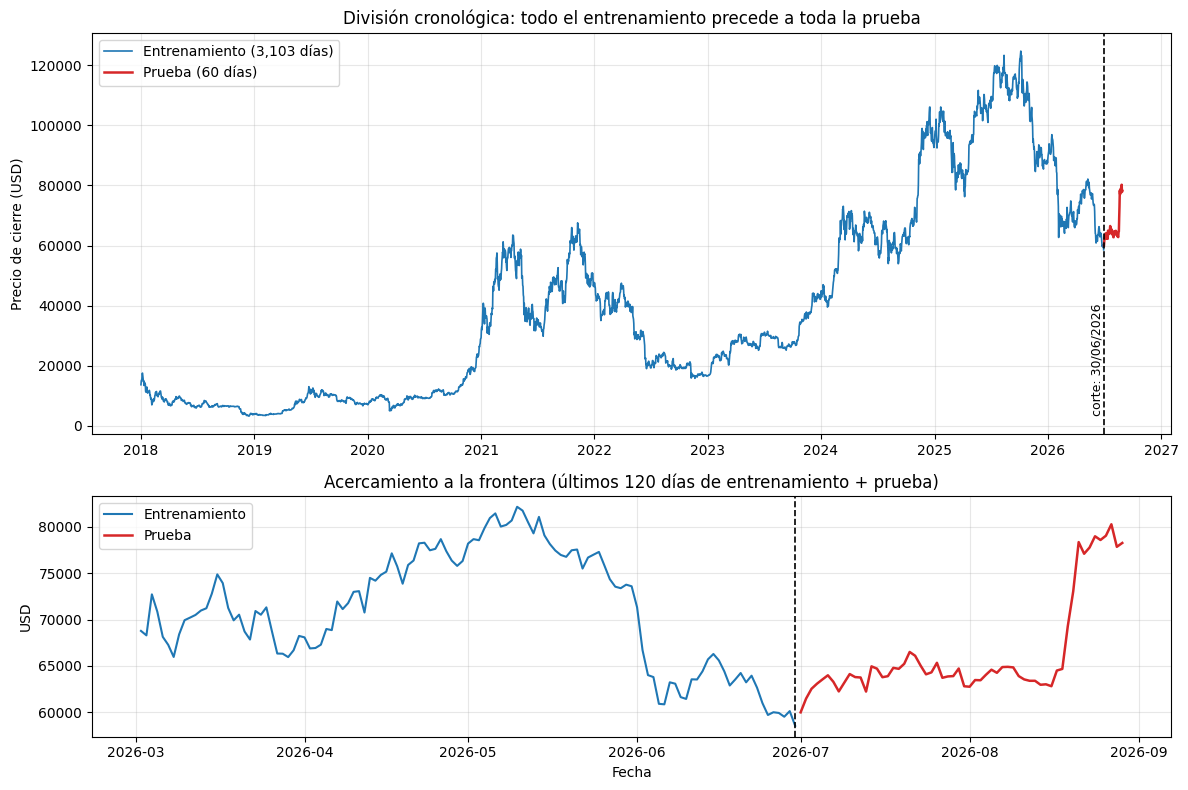

In [18]:
fig, ejes = plt.subplots(2, 1, figsize=(12, 8),
                         gridspec_kw={"height_ratios": [2, 1.2]})

# Panel superior: la serie completa con los dos bloques diferenciados
ejes[0].plot(df_train["ds"], df_train["y"], color="#1f77b4", lw=1.2,
             label=f"Entrenamiento ({len(df_train):,} días)")
ejes[0].plot(df_test["ds"], df_test["y"], color="#d62728", lw=1.8,
             label=f"Prueba ({len(df_test)} días)")
ejes[0].axvline(fecha_corte, color="black", ls="--", lw=1.2)
# Etiqueta en la zona baja del panel, donde no hay datos que tapar
ejes[0].annotate(f"corte: {fecha_corte:%d/%m/%Y} ", xy=(fecha_corte, df_prophet["y"].min()),
                 ha="right", va="bottom", fontsize=9, rotation=90)
ejes[0].set_title("División cronológica: todo el entrenamiento precede a toda la prueba")
ejes[0].set_ylabel("Precio de cierre (USD)")
ejes[0].legend(loc="upper left")

# Panel inferior: acercamiento a la frontera para ver bien el conjunto de prueba
ventana = df_prophet[df_prophet["ds"] >= fecha_corte - pd.Timedelta(days=120)]
ejes[1].plot(ventana[ventana["ds"] <= fecha_corte]["ds"],
             ventana[ventana["ds"] <= fecha_corte]["y"], color="#1f77b4", lw=1.5,
             label="Entrenamiento")
ejes[1].plot(df_test["ds"], df_test["y"], color="#d62728", lw=1.8, label="Prueba")
ejes[1].axvline(fecha_corte, color="black", ls="--", lw=1.2)
ejes[1].set_title("Acercamiento a la frontera (últimos 120 días de entrenamiento + prueba)")
ejes[1].set_xlabel("Fecha")
ejes[1].set_ylabel("USD")
ejes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

In [19]:
variacion_test = (df_test["y"].iloc[-1] / df_test["y"].iloc[0] - 1) * 100
tendencia_train_final = (df_train["y"].iloc[-1] / df_train["y"].iloc[-90] - 1) * 100

display(Markdown(f"""
### 🔎 ¿Cómo lo interpretamos?

- El entrenamiento cubre **{len(df_train):,} días** ({df_train['ds'].min():%d/%m/%Y} →
  {df_train['ds'].max():%d/%m/%Y}), es decir, el **{100 * len(df_train) / len(df_prophet):.1f} %**
  de la muestra. Es historia más que suficiente para que Prophet estime tendencia y estacionalidad
  anual.
- La prueba cubre **{len(df_test)} días** ({df_test['ds'].min():%d/%m/%Y} →
  {df_test['ds'].max():%d/%m/%Y}). El modelo **no verá ni uno solo** de estos valores.
- En los 90 días previos al corte el precio varió **{tendencia_train_final:+.1f} %**; durante el
  periodo de prueba varió **{variacion_test:+.1f} %**.

Anota ese último par de números: son la referencia contra la que juzgaremos el pronóstico. Prophet
no extrapola el movimiento de los últimos 90 días, sino la pendiente de la **tendencia de largo
plazo** que estime a partir de todo el histórico. Cuando ambas apuntan en direcciones distintas, el
error no es aleatorio: es una desviación sistemática que dura todo el horizonte. Compruébalo cuando
lleguemos a la sección 14.

Una limitación honesta de este diseño: estamos evaluando con **una sola ventana de 60 días**. Si esa
ventana resulta atípica, la conclusión será poco robusta. Por eso más adelante haremos **validación
cruzada temporal**, que repite el ejercicio sobre muchas ventanas distintas.
"""))


### 🔎 ¿Cómo lo interpretamos?

- El entrenamiento cubre **3,103 días** (01/01/2018 →
  30/06/2026), es decir, el **98.1 %**
  de la muestra. Es historia más que suficiente para que Prophet estime tendencia y estacionalidad
  anual.
- La prueba cubre **60 días** (01/07/2026 →
  29/08/2026). El modelo **no verá ni uno solo** de estos valores.
- En los 90 días previos al corte el precio varió **-12.5 %**; durante el
  periodo de prueba varió **+30.4 %**.

Anota ese último par de números: son la referencia contra la que juzgaremos el pronóstico. Prophet
no extrapola el movimiento de los últimos 90 días, sino la pendiente de la **tendencia de largo
plazo** que estime a partir de todo el histórico. Cuando ambas apuntan en direcciones distintas, el
error no es aleatorio: es una desviación sistemática que dura todo el horizonte. Compruébalo cuando
lleguemos a la sección 14.

Una limitación honesta de este diseño: estamos evaluando con **una sola ventana de 60 días**. Si esa
ventana resulta atípica, la conclusión será poco robusta. Por eso más adelante haremos **validación
cruzada temporal**, que repite el ejercicio sobre muchas ventanas distintas.


---

# 11. El modelo base

### 🎯 ¿Qué queremos hacer?
Construir un primer modelo **sencillo y justificado**, sin activar parámetros "porque sí".

### 🧠 ¿Por qué lo hacemos?
Un buen flujo de trabajo empieza por un modelo que se pueda explicar entero. Solo después, y
midiendo, se añade complejidad. Cada parámetro que activamos es una **afirmación sobre el mundo**, y
tenemos que poder defenderla.

### Los parámetros que sí fijamos

| Parámetro | Valor | Qué significa y por qué |
|---|---|---|
| `growth` | `"linear"` | La tendencia es **lineal a tramos**: rectas que pueden cambiar de pendiente en los *changepoints*. La alternativa, `"logistic"`, exige declarar una capacidad máxima (`cap`) de saturación; no existe ningún techo conocido para el precio de Bitcoin, así que sería inventarse un supuesto. |
| `interval_width` | `0.95` | Ancho del intervalo de incertidumbre. Por defecto es `0.80`; lo subimos al 95 % para que la banda sea más conservadora y visualmente más informativa. **No hace al modelo más preciso**: solo ensancha la banda. |
| `weekly_seasonality` | `True` | Tenemos años de datos diarios, así que se puede estimar un patrón semanal. Será interesante ver si resulta relevante o despreciable. |
| `yearly_seasonality` | `True` | Con ~6,5 años de historia hay suficientes ciclos anuales para intentar estimarlo. |
| `daily_seasonality` | `False` | **Aquí corregimos un error frecuente.** Ver la nota siguiente. |

### ⚠️ Por qué `daily_seasonality=False`

La "estacionalidad diaria" de Prophet modela el patrón **dentro de un día**: cómo varía la serie
entre las 3 de la mañana y las 6 de la tarde. Para estimarla se necesitan **varias observaciones por
día** (datos horarios o por minuto).

Nuestros datos son **un valor por día**. Pedir estacionalidad intradiaria con datos diarios es pedir
que el modelo describa un patrón del que **no tiene ni una sola observación**: en el mejor de los
casos no aporta nada y en el peor añade parámetros que solo sirven para sobreajustar el ruido. Por
eso el modelo original del que parte este notebook, con `daily_seasonality=True`, estaba mal
especificado.

De hecho, Prophet aplica por sí mismo esta regla: **detecta automáticamente** qué estacionalidades
puede estimar según la frecuencia y la longitud de los datos. Con datos diarios desactiva la diaria;
con menos de dos años, desactiva la anual. Fijar el valor explícitamente hace la decisión visible y
documentada en lugar de dejarla implícita.

> ### 💡 Idea clave
> Una estacionalidad solo se puede estimar si los datos tienen **resolución suficiente** para verla y
> **duración suficiente** para verla repetirse varias veces.

In [20]:
modelo = Prophet(
    growth="linear",          # tendencia lineal a tramos
    interval_width=0.95,      # intervalo de incertidumbre del 95 %
    yearly_seasonality=True,  # ~6,5 años de historia: hay ciclos anuales suficientes
    weekly_seasonality=True,  # datos diarios: el patrón semanal es estimable
    daily_seasonality=False,  # no hay datos intradía: no hay nada que estimar
)
print("Modelo creado (todavía sin entrenar).")
print("Estacionalidades declaradas:", list(modelo.seasonalities.keys()) or "(se añaden al ajustar)")

Modelo creado (todavía sin entrenar).
Estacionalidades declaradas: (se añaden al ajustar)


---

# 12. Entrenamiento del modelo

### 🎯 ¿Qué queremos hacer?
Ajustar el modelo usando **exclusivamente** `df_train`.

### 🧠 ¿Qué significa "ajustar" o "entrenar"?
El modelo tiene una forma general —$y(t) = g(t) + s(t) + \epsilon_t$— pero sus **parámetros** están
en blanco: ¿cuál es la pendiente inicial de la tendencia?, ¿cuánto cambia en cada *changepoint*?,
¿qué amplitud tiene la onda semanal?

Entrenar es **buscar los valores de esos parámetros que mejor reconcilian el modelo con los datos
observados**. Prophet lo hace por optimización: encuentra el conjunto de parámetros más probable
(estimación MAP) penalizando las soluciones demasiado flexibles. Ese castigo a la flexibilidad es lo
que impide que la tendencia se retuerza para pasar por cada punto.

> ### 🔎 Idea clave
> Prophet utiliza **únicamente la información disponible hasta la fecha final del conjunto de
> entrenamiento**. Todo lo que ocurra después es, para el modelo, territorio desconocido: la
> siguiente celda lo comprueba imprimiendo la última fecha que el modelo llegó a ver.
> Esta es la razón de ser de la división cronológica de la sección anterior.

In [21]:
import time

inicio = time.time()
modelo.fit(df_train)
duracion = time.time() - inicio

print(f"Modelo entrenado en {duracion:.1f} segundos.")
print(f"Datos usados : {len(df_train):,} observaciones")
print(f"Periodo      : {df_train['ds'].min():%Y-%m-%d} → {df_train['ds'].max():%Y-%m-%d}")
print(f"\nEstacionalidades activas en el modelo ajustado:")
for nombre, config in modelo.seasonalities.items():
    print(f"  - {nombre}: periodo = {config['period']} días, "
          f"orden de Fourier = {config['fourier_order']}, modo = {config['mode']}")
print(f"\nPuntos de cambio candidatos: {len(modelo.changepoints)}")
print(f"Último dato conocido por el modelo: {modelo.history['ds'].max():%Y-%m-%d}")

Modelo entrenado en 3.1 segundos.
Datos usados : 3,103 observaciones
Periodo      : 2018-01-01 → 2026-06-30

Estacionalidades activas en el modelo ajustado:
  - yearly: periodo = 365.25 días, orden de Fourier = 10, modo = additive
  - weekly: periodo = 7 días, orden de Fourier = 3, modo = additive

Puntos de cambio candidatos: 25
Último dato conocido por el modelo: 2026-06-30


### 🔎 ¿Cómo lo interpretamos?

Tres cosas que conviene leer en la salida:

- **Estacionalidades activas.** Prophet confirmó `weekly` (periodo 7, orden de Fourier 3) y `yearly`
  (periodo 365,25, orden 10). El **orden de Fourier** indica cuántos pares seno-coseno se usan para
  dibujar la curva estacional: cuanto mayor, más "rizada" puede ser la forma y mayor el riesgo de
  sobreajuste. No aparece ninguna estacionalidad diaria, como queríamos.
- **Puntos de cambio candidatos.** Son 25 por defecto, repartidos en el primer 80 % del
  entrenamiento. Son *candidatos*: el modelo puede dejar casi todos en cero.
- **Último dato conocido.** Coincide exactamente con el final del entrenamiento. Si aquí apareciera
  una fecha dentro del periodo de prueba, tendríamos una fuga de información.

---

# 13. Generación del pronóstico

### 🎯 ¿Qué queremos hacer?
Predecir exactamente los mismos días que contiene el conjunto de prueba.

### 🧠 ¿Por qué lo hacemos?
Para poder comparar predicción y realidad, ambas deben referirse a **las mismas fechas**. Por eso el
horizonte no se escribe a mano (`periods=60`), sino que se **deriva del conjunto de prueba**:

```python
periodos = len(df_test)
```

Así, si cambias `DIAS_PRUEBA`, el horizonte se ajusta solo y no puede desincronizarse. Escribir el
número a mano es una fuente clásica de errores silenciosos: el gráfico sale bonito, pero las métricas
se calculan sobre fechas que no se corresponden.

**Detalle importante sobre `make_future_dataframe`:** no crea solo el futuro. Devuelve el histórico
completo de entrenamiento **más** los `periods` días nuevos. Por eso `forecast` tendrá más filas que
`df_test`: contiene tanto el ajuste dentro de la muestra como la extrapolación.

In [22]:
periodos = len(df_test)   # el horizonte SIEMPRE coincide con el conjunto de prueba

futuro = modelo.make_future_dataframe(periods=periodos, freq="D")
forecast = modelo.predict(futuro)

print(f"Horizonte de pronóstico : {periodos} días")
print(f"Filas en 'futuro'       : {len(futuro):,}  "
      f"(= {len(df_train):,} de entrenamiento + {periodos} futuros)")
print(f"Rango de 'futuro'       : {futuro['ds'].min():%Y-%m-%d} → {futuro['ds'].max():%Y-%m-%d}")
print(f"Última fecha de prueba  : {df_test['ds'].max():%Y-%m-%d}")

# Verificamos que las fechas pronosticadas coinciden con las de prueba.
fechas_futuras = set(futuro["ds"]) - set(df_train["ds"])
assert fechas_futuras == set(df_test["ds"]), "El horizonte no coincide con el conjunto de prueba."
print("\n✓ Las fechas pronosticadas coinciden exactamente con las del conjunto de prueba.")

Horizonte de pronóstico : 60 días
Filas en 'futuro'       : 3,163  (= 3,103 de entrenamiento + 60 futuros)
Rango de 'futuro'       : 2018-01-01 → 2026-08-29
Última fecha de prueba  : 2026-08-29

✓ Las fechas pronosticadas coinciden exactamente con las del conjunto de prueba.


In [23]:
# El objeto 'forecast' trae muchas columnas; al principio solo nos interesan cuatro.
print(f"'forecast' tiene {forecast.shape[1]} columnas. Las cuatro esenciales:\n")
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(10)

'forecast' tiene 19 columnas. Las cuatro esenciales:



,ds,yhat,yhat_lower,yhat_upper
3153,2026-08-20,"87,781.05","69,149.44","105,566.02"
3154,2026-08-21,"87,687.84","69,915.45","106,617.38"
3155,2026-08-22,"87,568.50","69,430.92","105,738.81"
3156,2026-08-23,"87,468.41","68,907.10","106,225.93"
3157,2026-08-24,"87,442.57","68,077.87","105,504.53"
3158,2026-08-25,"87,218.77","68,359.42","105,584.25"
3159,2026-08-26,"87,272.97","69,000.18","105,175.58"
3160,2026-08-27,"86,957.49","67,602.17","105,226.84"
3161,2026-08-28,"86,824.56","68,017.28","103,703.62"
3162,2026-08-29,"86,674.68","68,337.91","105,036.50"


### 🔎 ¿Qué significan `yhat`, `yhat_lower` y `yhat_upper`?

| Columna | Significado |
|---|---|
| **`yhat`** | La predicción puntual: el valor **más probable** según el modelo. Es la suma de todos los componentes: tendencia + estacionalidad semanal + estacionalidad anual. |
| **`yhat_lower`** | Extremo **inferior** del intervalo de incertidumbre del 95 %. |
| **`yhat_upper`** | Extremo **superior** del mismo intervalo. |

La interpretación correcta del intervalo es: *"bajo los supuestos del modelo, el valor real debería
caer dentro de esta banda aproximadamente el 95 % de las veces"*. Dos advertencias:

1. **La incertidumbre de Prophet proviene sobre todo de la tendencia**, no de la estacionalidad: el
   modelo simula posibles cambios futuros de pendiente similares a los observados en el pasado. Por
   eso la banda se abre en forma de embudo a medida que nos alejamos.
2. **El intervalo describe la incertidumbre *del modelo*, no la del mundo.** Si el modelo está mal
   especificado, la banda puede ser cómodamente estrecha y estar cómodamente equivocada. Más
   adelante mediremos su **cobertura real**.

> ### 💡 Idea clave
> Un pronóstico sin intervalo es una opinión disfrazada de número. `yhat` sin `yhat_lower` y
> `yhat_upper` oculta justo lo que un tomador de decisiones necesita saber: cuánta confianza merece.

---

# 14. Comparación entre lo real y lo pronosticado

### 🎯 ¿Qué queremos hacer?
Juntar en una sola tabla los valores reales de prueba y las predicciones del modelo, y visualizarlos.

### 🧠 ¿Por qué lo hacemos?
Todas las métricas que calcularemos después salen de esta tabla. Construirla con un `merge` **sobre
la fecha** (y no pegando columnas por posición) garantiza que cada predicción se compara con el día
que le corresponde.

In [24]:
comparacion = df_test.merge(
    forecast[["ds", "yhat", "yhat_lower", "yhat_upper", "trend"]],
    on="ds", how="left",
).rename(columns={"y": "y_real"})

# Si el merge dejara algún NaN, alguna fecha no se habría pronosticado.
assert comparacion[["yhat", "yhat_lower", "yhat_upper"]].notna().all().all(), \
    "Hay fechas de prueba sin pronóstico."

comparacion["error"] = comparacion["y_real"] - comparacion["yhat"]
comparacion["error_%"] = 100 * comparacion["error"] / comparacion["y_real"]
comparacion["dentro_intervalo"] = (
    comparacion["y_real"].between(comparacion["yhat_lower"], comparacion["yhat_upper"])
)

print(f"{len(comparacion)} días comparados. Primeros y últimos 5:\n")
display(comparacion[["ds", "y_real", "yhat", "yhat_lower", "yhat_upper", "error", "error_%"]].head())
display(comparacion[["ds", "y_real", "yhat", "yhat_lower", "yhat_upper", "error", "error_%"]].tail())

60 días comparados. Primeros y últimos 5:



,ds,y_real,yhat,yhat_lower,yhat_upper,error,error_%
0,2026-07-01,"60,003.76","85,193.98","68,241.19","104,801.85","-25,190.22",-41.98
1,2026-07-02,"61,485.30","85,196.75","66,480.15","103,893.20","-23,711.45",-38.56
2,2026-07-03,"62,544.20","85,396.04","66,606.46","104,076.26","-22,851.84",-36.54
3,2026-07-04,"63,088.30","85,588.01","65,829.93","104,852.88","-22,499.70",-35.66
4,2026-07-05,"63,547.88","85,814.54","66,682.35","104,566.34","-22,266.66",-35.04


,ds,y_real,yhat,yhat_lower,yhat_upper,error,error_%
55,2026-08-25,"78,564.98","87,218.77","68,359.42","105,584.25","-8,653.79",-11.01
56,2026-08-26,"79,027.42","87,272.97","69,000.18","105,175.58","-8,245.55",-10.43
57,2026-08-27,"80,257.54","86,957.49","67,602.17","105,226.84","-6,699.95",-8.35
58,2026-08-28,"77,830.29","86,824.56","68,017.28","103,703.62","-8,994.27",-11.56
59,2026-08-29,"78,245.81","86,674.68","68,337.91","105,036.50","-8,428.87",-10.77


In [25]:
# --- Gráfica interactiva: entrenamiento, realidad y pronóstico ---
contexto = df_train.tail(180)   # últimos 6 meses de entrenamiento, para dar contexto
prevision = forecast[forecast["ds"] > df_train["ds"].max()]

fig = go.Figure()

# Banda de incertidumbre (se dibuja primero para que quede al fondo)
fig.add_trace(go.Scatter(
    x=prevision["ds"], y=prevision["yhat_upper"], mode="lines",
    line=dict(width=0), showlegend=False, hoverinfo="skip",
))
fig.add_trace(go.Scatter(
    x=prevision["ds"], y=prevision["yhat_lower"], mode="lines",
    line=dict(width=0), fill="tonexty", fillcolor="rgba(44,160,44,0.18)",
    name="Intervalo 95 %", hoverinfo="skip",
))

fig.add_trace(go.Scatter(
    x=contexto["ds"], y=contexto["y"], mode="lines", name="Entrenamiento (real)",
    line=dict(color="#1f77b4", width=1.6),
    hovertemplate="%{x|%d %b %Y}<br>Real: %{y:$,.0f}<extra></extra>",
))
fig.add_trace(go.Scatter(
    x=comparacion["ds"], y=comparacion["y_real"], mode="lines", name="Prueba (real)",
    line=dict(color="#d62728", width=2.2),
    hovertemplate="%{x|%d %b %Y}<br>Real: %{y:$,.0f}<extra></extra>",
))
fig.add_trace(go.Scatter(
    x=prevision["ds"], y=prevision["yhat"], mode="lines", name="Pronóstico (yhat)",
    line=dict(color="#2ca02c", width=2.2, dash="dash"),
    hovertemplate="%{x|%d %b %Y}<br>Pronóstico: %{y:$,.0f}<extra></extra>",
))

fig.add_vline(x=df_train["ds"].max(), line_width=1.2, line_dash="dot", line_color="black")
fig.add_annotation(x=df_train["ds"].max(), y=1, yref="paper",
                   text="fin del entrenamiento", showarrow=False,
                   xanchor="right", font=dict(size=11))

fig.update_layout(
    title=f"{TICKER}: real frente a pronosticado en los {len(df_test)} días de prueba",
    xaxis_title="Fecha", yaxis_title="Precio de cierre (USD)",
    template="plotly_white", height=520, hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig.show()

In [26]:
# Lectura automática de la gráfica, a partir de los números reales
sesgo = comparacion["error"].mean()
sesgo_pct = comparacion["error_%"].mean()
cobertura = 100 * comparacion["dentro_intervalo"].mean()
ancho_medio = (comparacion["yhat_upper"] - comparacion["yhat_lower"]).mean()
ancho_rel = 100 * ancho_medio / comparacion["y_real"].mean()

direccion_real = np.sign(comparacion["y_real"].iloc[-1] - comparacion["y_real"].iloc[0])
direccion_pred = np.sign(comparacion["yhat"].iloc[-1] - comparacion["yhat"].iloc[0])
acierta_direccion = direccion_real == direccion_pred

volatilidad_real = comparacion["y_real"].pct_change().std() * 100
volatilidad_pred = comparacion["yhat"].pct_change().std() * 100

if sesgo < 0:
    texto_sesgo = (f"El error medio es **{sesgo:,.0f} USD** ({sesgo_pct:+.1f} %), negativo: en "
                   f"promedio el modelo **sobreestimó** el precio, es decir, pronosticó valores "
                   f"más altos que los observados.")
else:
    texto_sesgo = (f"El error medio es **{sesgo:,.0f} USD** ({sesgo_pct:+.1f} %), positivo: en "
                   f"promedio el modelo **subestimó** el precio, es decir, pronosticó valores más "
                   f"bajos que los observados.")

texto_direccion = ("**acertó** el sentido general del movimiento" if acierta_direccion
                   else "**se equivocó** en el sentido general del movimiento")

display(Markdown(f"""
### 🔎 ¿Cómo interpretamos esta gráfica?

Hay cuatro preguntas que siempre vale la pena hacerle a un gráfico de pronóstico:

**1. ¿Sigue el modelo la dirección general?**
Entre el primer y el último día de prueba, el precio real se movió
{comparacion['y_real'].iloc[-1] - comparacion['y_real'].iloc[0]:+,.0f} USD y el pronóstico
{comparacion['yhat'].iloc[-1] - comparacion['yhat'].iloc[0]:+,.0f} USD. El modelo {texto_direccion}.

**2. ¿Sobreestima o subestima?**
{texto_sesgo} Un sesgo sistemático en una sola dirección es la firma de un modelo que **extrapoló la
pendiente reciente del entrenamiento** y se mantuvo fiel a ella mientras la realidad hacía otra cosa.

**3. ¿Reacciona a los cambios bruscos?**
No, y no puede hacerlo. A partir del último dato de entrenamiento, `yhat` es una curva **suave**:
tendencia más estacionalidad, sin ninguna información nueva que la corrija. La desviación típica de
las variaciones diarias fue de **{volatilidad_real:.2f} %** en la serie real frente a
**{volatilidad_pred:.2f} %** en el pronóstico. El modelo produce un pronóstico
**{volatilidad_real / max(volatilidad_pred, 1e-9):.0f} veces más liso** que la realidad.

**4. ¿Es honesto el intervalo de incertidumbre?**
El **{cobertura:.0f} %** de los valores reales cayó dentro de la banda del 95 % (lo esperado sería
cerca del 95 %). La banda tiene un ancho medio de **{ancho_medio:,.0f} USD**, alrededor del
**{ancho_rel:.0f} %** del precio medio del periodo.

> ### 💡 Idea clave
> Prophet no predice el **camino** de la serie, sino su **nivel medio esperado**. Esperar que `yhat`
> reproduzca los altibajos diarios es pedirle algo que no hace ningún modelo de este tipo: si la
> parte impredecible es ruido, el mejor pronóstico posible es precisamente una curva suave.
"""))


### 🔎 ¿Cómo interpretamos esta gráfica?

Hay cuatro preguntas que siempre vale la pena hacerle a un gráfico de pronóstico:

**1. ¿Sigue el modelo la dirección general?**
Entre el primer y el último día de prueba, el precio real se movió
+18,242 USD y el pronóstico
+1,481 USD. El modelo **acertó** el sentido general del movimiento.

**2. ¿Sobreestima o subestima?**
El error medio es **-21,370 USD** (-33.0 %), negativo: en promedio el modelo **sobreestimó** el precio, es decir, pronosticó valores más altos que los observados. Un sesgo sistemático en una sola dirección es la firma de un modelo que **extrapoló la
pendiente reciente del entrenamiento** y se mantuvo fiel a ella mientras la realidad hacía otra cosa.

**3. ¿Reacciona a los cambios bruscos?**
No, y no puede hacerlo. A partir del último dato de entrenamiento, `yhat` es una curva **suave**:
tendencia más estacionalidad, sin ninguna información nueva que la corrija. La desviación típica de
las variaciones diarias fue de **1.99 %** en la serie real frente a
**0.18 %** en el pronóstico. El modelo produce un pronóstico
**11 veces más liso** que la realidad.

**4. ¿Es honesto el intervalo de incertidumbre?**
El **17 %** de los valores reales cayó dentro de la banda del 95 % (lo esperado sería
cerca del 95 %). La banda tiene un ancho medio de **37,169 USD**, alrededor del
**56 %** del precio medio del periodo.

> ### 💡 Idea clave
> Prophet no predice el **camino** de la serie, sino su **nivel medio esperado**. Esperar que `yhat`
> reproduzca los altibajos diarios es pedirle algo que no hace ningún modelo de este tipo: si la
> parte impredecible es ruido, el mejor pronóstico posible es precisamente una curva suave.


---

# 15. Métricas de error sobre el conjunto de prueba

### 🎯 ¿Qué queremos hacer?
Traducir "el pronóstico se ve más o menos bien" a números comparables.

### 🧠 ¿Por qué lo hacemos?
La vista engaña: una gráfica con el eje vertical entre 50.000 y 70.000 USD hace que un error de
5.000 USD parezca minúsculo. Las métricas evitan esa ilusión y, sobre todo, **permiten comparar
modelos entre sí**.

Todas parten del error de cada día, $e_t = y_t - \hat{y}_t$:

| Métrica | Fórmula | Unidad | Qué aporta | Cuidado |
|---|---|---|---|---|
| **MAE** | $\frac{1}{n}\sum \lvert e_t \rvert$ | USD | Error promedio, fácil de explicar: "nos equivocamos en X dólares al día" | Trata igual un error grande que muchos pequeños |
| **RMSE** | $\sqrt{\frac{1}{n}\sum e_t^2}$ | USD | **Penaliza más los errores grandes** por elevar al cuadrado | Muy sensible a un solo día catastrófico |
| **MAPE** | $\frac{100}{n}\sum \left\lvert \frac{e_t}{y_t} \right\rvert$ | % | Independiente de la escala: permite comparar activos distintos | No definido si $y_t = 0$; penaliza más las sobreestimaciones |
| **sMAPE** | $\frac{100}{n}\sum \frac{2\lvert e_t \rvert}{\lvert y_t \rvert + \lvert \hat{y}_t \rvert}$ | % | Versión "simétrica" del MAPE, más estable | Su interpretación es menos intuitiva |

Una lectura útil: **si RMSE es mucho mayor que MAE, hay días con errores muy grandes**. Si son
parecidos, los errores están repartidos de forma pareja.

### Una nota sobre `sklearn`
Podríamos importar `mean_squared_error` de `scikit-learn`, pero el argumento `squared=False` —la
forma habitual de obtener el RMSE— quedó obsoleto y fue eliminado en versiones recientes, de modo
que el mismo código falla o avisa según la versión instalada. Como son cuatro líneas de NumPy, las
escribimos nosotros: **menos dependencias y control total sobre lo que se calcula**.

In [27]:
def calcular_metricas(y_real, y_pred, nombre="modelo"):
    """Calcula MAE, RMSE, MAPE y sMAPE sin depender de scikit-learn."""
    y_real = np.asarray(y_real, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    error = y_real - y_pred
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    mape = np.mean(np.abs(error / y_real)) * 100
    smape = np.mean(2 * np.abs(error) / (np.abs(y_real) + np.abs(y_pred))) * 100

    return {"Modelo": nombre, "MAE": mae, "RMSE": rmse,
            "MAPE (%)": mape, "sMAPE (%)": smape}


metricas_prophet = calcular_metricas(comparacion["y_real"], comparacion["yhat"], "Prophet (base)")

tabla_metricas = pd.DataFrame([metricas_prophet]).set_index("Modelo")
display(tabla_metricas.style.format("{:,.2f}"))

,MAE,RMSE,MAPE (%),sMAPE (%)
Modelo,,,,
Prophet (base),"21,369.58","22,074.08",33.01,28.02


In [28]:
precio_medio_test = comparacion["y_real"].mean()
ratio_rmse_mae = metricas_prophet["RMSE"] / metricas_prophet["MAE"]
lectura_rmse = ("hay días claramente peores que la media" if ratio_rmse_mae > 1.15
                else "los errores están repartidos de forma bastante uniforme")

display(Markdown(f"""
### 🔎 ¿Cómo lo interpretamos?

| Métrica | Resultado | Interpretación |
|---|---:|---|
| **MAE** | {metricas_prophet['MAE']:,.0f} USD | En un día cualquiera del periodo de prueba, el pronóstico se alejó del precio real unos **{metricas_prophet['MAE']:,.0f} dólares** en promedio. |
| **RMSE** | {metricas_prophet['RMSE']:,.0f} USD | Igual que el MAE pero castigando los errores grandes. Es un **{100 * (ratio_rmse_mae - 1):.0f} %** mayor que el MAE, señal de que {lectura_rmse}. |
| **MAPE** | {metricas_prophet['MAPE (%)']:.2f} % | El error equivale, en promedio, al **{metricas_prophet['MAPE (%)']:.1f} %** del precio del día. Sobre un precio medio de {precio_medio_test:,.0f} USD, eso son unos {precio_medio_test * metricas_prophet['MAPE (%)'] / 100:,.0f} USD. |
| **sMAPE** | {metricas_prophet['sMAPE (%)']:.2f} % | Versión simétrica del MAPE. Su cercanía al MAPE indica que no hay una asimetría extrema entre sobre y subestimación. |

**¿Es bueno un MAPE de {metricas_prophet['MAPE (%)']:.1f} %?** La pregunta, tal como está formulada,
no tiene respuesta. Un {metricas_prophet['MAPE (%)']:.1f} % sería excelente pronosticando el consumo
eléctrico de una ciudad y pésimo pronosticando la hora de salida de un tren. **Una métrica aislada
no significa nada: solo adquiere sentido comparada con otra cosa.**

Eso es exactamente lo que hacemos en la sección siguiente.

> ### 💡 Idea clave
> Nunca informes un error sin una referencia contra la cual compararlo. La primera referencia
> obligatoria es siempre el modelo más tonto que se te ocurra.
"""))


### 🔎 ¿Cómo lo interpretamos?

| Métrica | Resultado | Interpretación |
|---|---:|---|
| **MAE** | 21,370 USD | En un día cualquiera del periodo de prueba, el pronóstico se alejó del precio real unos **21,370 dólares** en promedio. |
| **RMSE** | 22,074 USD | Igual que el MAE pero castigando los errores grandes. Es un **3 %** mayor que el MAE, señal de que los errores están repartidos de forma bastante uniforme. |
| **MAPE** | 33.01 % | El error equivale, en promedio, al **33.0 %** del precio del día. Sobre un precio medio de 66,296 USD, eso son unos 21,887 USD. |
| **sMAPE** | 28.02 % | Versión simétrica del MAPE. Su cercanía al MAPE indica que no hay una asimetría extrema entre sobre y subestimación. |

**¿Es bueno un MAPE de 33.0 %?** La pregunta, tal como está formulada,
no tiene respuesta. Un 33.0 % sería excelente pronosticando el consumo
eléctrico de una ciudad y pésimo pronosticando la hora de salida de un tren. **Una métrica aislada
no significa nada: solo adquiere sentido comparada con otra cosa.**

Eso es exactamente lo que hacemos en la sección siguiente.

> ### 💡 Idea clave
> Nunca informes un error sin una referencia contra la cual compararlo. La primera referencia
> obligatoria es siempre el modelo más tonto que se te ocurra.


---

# 16. ¿Prophet realmente mejora una predicción sencilla?

### 🎯 ¿Qué queremos hacer?
Comparar Prophet con el modelo más simple imaginable.

### 🧠 ¿Por qué lo hacemos?
Un modelo complejo **solo es útil si mejora las alternativas simples**. Si un modelo con
estacionalidades, puntos de cambio e inferencia bayesiana no le gana a una regla de una línea, el
modelo no está aportando nada y solo está añadiendo costo, riesgo y una falsa sensación de rigor.

### El modelo ingenuo (*naive* o de paseo aleatorio)

> **El precio de mañana será igual al último precio observado.**

Es decir, $\hat{y}_{T+h} = y_T$ para todo horizonte $h$: una línea horizontal desde el último dato
de entrenamiento. No tiene parámetros, no se entrena y se implementa en una línea.

Aunque parezca ridículo, tiene un fundamento teórico sólido: si una serie sigue un **paseo
aleatorio** —como predice aproximadamente la hipótesis de eficiencia de los mercados para el precio
de un activo—, entonces el valor de hoy es, formalmente, **el mejor predictor posible** del valor de
mañana. Por eso el modelo ingenuo es un rival temible en finanzas.

Añadimos un segundo competidor, la **deriva** (*drift*), que prolonga la recta que une el primer y el
último punto del entrenamiento: representa "seguir creciendo al ritmo medio histórico".

In [29]:
ultimo_precio = df_train["y"].iloc[-1]
horizonte = np.arange(1, len(df_test) + 1)

# Modelo 1: ingenuo (naive) — el último precio observado, repetido
pred_naive = np.full(len(df_test), ultimo_precio)

# Modelo 2: deriva (drift) — prolonga la pendiente media de todo el entrenamiento
pendiente_media = (df_train["y"].iloc[-1] - df_train["y"].iloc[0]) / (len(df_train) - 1)
pred_drift = ultimo_precio + pendiente_media * horizonte

print(f"Último precio de entrenamiento ({df_train['ds'].max():%Y-%m-%d}): {ultimo_precio:,.0f} USD")
print(f"Pendiente media histórica: {pendiente_media:+,.2f} USD/día")
print(f"Pronóstico 'deriva' al día {len(df_test)}: {pred_drift[-1]:,.0f} USD")

Último precio de entrenamiento (2026-06-30): 58,559 USD
Pendiente media histórica: +14.48 USD/día
Pronóstico 'deriva' al día 60: 59,427 USD


In [30]:
comparativa = pd.DataFrame([
    metricas_prophet,
    calcular_metricas(comparacion["y_real"], pred_naive, "Ingenuo (último valor)"),
    calcular_metricas(comparacion["y_real"], pred_drift, "Deriva (drift)"),
]).set_index("Modelo")

display(comparativa.style.format("{:,.2f}").background_gradient(cmap="RdYlGn_r", axis=0))

,MAE,RMSE,MAPE (%),sMAPE (%)
Modelo,,,,
Prophet (base),"21,369.58","22,074.08",33.01,28.02
Ingenuo (último valor),"7,736.91","9,428.25",11.15,12.07
Deriva (drift),"7,295.42","8,970.01",10.50,11.32


In [31]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=comparacion["ds"], y=comparacion["y_real"], mode="lines",
                         name="Real", line=dict(color="#d62728", width=2.4)))
fig.add_trace(go.Scatter(x=comparacion["ds"], y=comparacion["yhat"], mode="lines",
                         name="Prophet", line=dict(color="#2ca02c", width=2, dash="dash")))
fig.add_trace(go.Scatter(x=comparacion["ds"], y=pred_naive, mode="lines",
                         name="Ingenuo", line=dict(color="#7f7f7f", width=2, dash="dot")))
fig.add_trace(go.Scatter(x=comparacion["ds"], y=pred_drift, mode="lines",
                         name="Deriva", line=dict(color="#ff7f0e", width=2, dash="dashdot")))
fig.update_layout(
    title="Tres pronósticos frente a la realidad en el periodo de prueba",
    xaxis_title="Fecha", yaxis_title="Precio de cierre (USD)",
    template="plotly_white", height=460, hovermode="x unified",
)
fig.show()

In [32]:
mejor = comparativa["MAE"].idxmin()
mae_prophet = comparativa.loc["Prophet (base)", "MAE"]
mae_naive = comparativa.loc["Ingenuo (último valor)", "MAE"]
diferencia_pct = 100 * (mae_prophet - mae_naive) / mae_naive

if mae_prophet < mae_naive:
    lectura = (f"Prophet obtuvo un MAE **{abs(diferencia_pct):.0f} % menor** que el modelo ingenuo "
               f"en esta ventana concreta.")
else:
    lectura = (f"Prophet obtuvo un MAE **{abs(diferencia_pct):.0f} % mayor** que el modelo ingenuo: "
               f"en esta ventana, repetir el último precio habría funcionado mejor que todo el "
               f"aparato de tendencia y estacionalidad.")

display(Markdown(f"""
### 🔎 ¿Cómo lo interpretamos?

Según el MAE, el mejor de los tres en este periodo fue **{mejor}**. {lectura}

Antes de sacar conclusiones fuertes, tres cautelas:

1. **Es una sola ventana de {len(df_test)} días.** Con otra fecha de corte el orden podría
   invertirse. Por eso la validación cruzada de la sección 19 es imprescindible: no para adornar el
   análisis, sino para saber si este resultado es estable o casualidad.
2. **El modelo ingenuo es un rival serio, no un chiste.** Si el precio se comporta como un paseo
   aleatorio, es muy difícil de batir de forma consistente. Que a veces le gane un modelo elaborado
   no demuestra que ese modelo haya "entendido" la serie.
3. **Ganar en una métrica no es ganar en todas.** Comprueba en la tabla si el orden de los modelos
   se mantiene al mirar RMSE y MAPE; si cambia, es que cada métrica está premiando un tipo distinto
   de acierto.

> ### 💡 Idea clave
> El *baseline* no es un trámite: es la vara de medir. Un modelo que no supera de forma **consistente**
> a la regla trivial no debería llegar a producción, por sofisticado que sea.
"""))


### 🔎 ¿Cómo lo interpretamos?

Según el MAE, el mejor de los tres en este periodo fue **Deriva (drift)**. Prophet obtuvo un MAE **176 % mayor** que el modelo ingenuo: en esta ventana, repetir el último precio habría funcionado mejor que todo el aparato de tendencia y estacionalidad.

Antes de sacar conclusiones fuertes, tres cautelas:

1. **Es una sola ventana de 60 días.** Con otra fecha de corte el orden podría
   invertirse. Por eso la validación cruzada de la sección 19 es imprescindible: no para adornar el
   análisis, sino para saber si este resultado es estable o casualidad.
2. **El modelo ingenuo es un rival serio, no un chiste.** Si el precio se comporta como un paseo
   aleatorio, es muy difícil de batir de forma consistente. Que a veces le gane un modelo elaborado
   no demuestra que ese modelo haya "entendido" la serie.
3. **Ganar en una métrica no es ganar en todas.** Comprueba en la tabla si el orden de los modelos
   se mantiene al mirar RMSE y MAPE; si cambia, es que cada métrica está premiando un tipo distinto
   de acierto.

> ### 💡 Idea clave
> El *baseline* no es un trámite: es la vara de medir. Un modelo que no supera de forma **consistente**
> a la regla trivial no debería llegar a producción, por sofisticado que sea.


---

# 17. Descomposición: los componentes del modelo

### 🎯 ¿Qué queremos hacer?
Abrir el modelo y mirar por separado cada una de las piezas de
$y(t) = g(t) + s(t) + \epsilon_t$.

### 🧠 ¿Por qué lo hacemos?
Esta es la gran ventaja didáctica de Prophet: el pronóstico no es una caja negra, sino una **suma de
curvas que se pueden dibujar**. `plot_components` muestra cada sumando, de modo que podemos juzgar
si lo que el modelo aprendió tiene sentido.

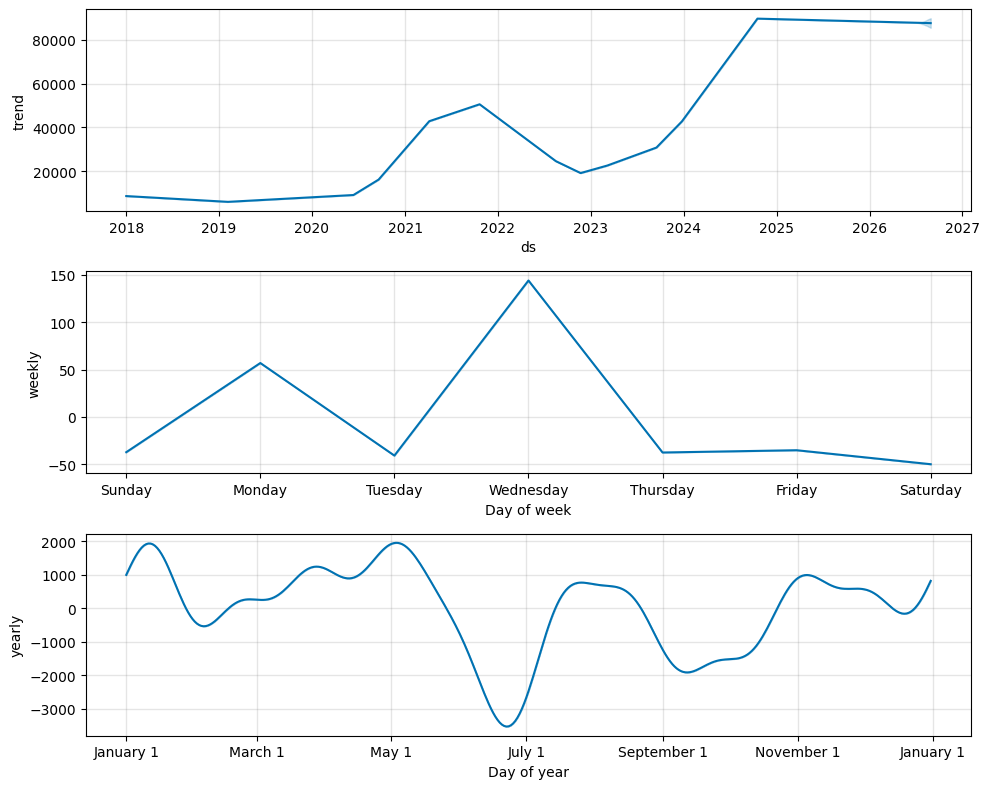

In [33]:
fig = modelo.plot_components(forecast, figsize=(10, 8))
plt.tight_layout()
plt.show()

In [34]:
# Cuantificamos la importancia de cada componente para no juzgar "a ojo".
# Cada panel del gráfico anterior usa su propia escala vertical, lo que puede
# hacer parecer grande un efecto minúsculo.
amplitud_tendencia = forecast["trend"].max() - forecast["trend"].min()
amplitud_semanal = forecast["weekly"].max() - forecast["weekly"].min()
amplitud_anual = forecast["yearly"].max() - forecast["yearly"].min()
precio_medio = df_prophet["y"].mean()

resumen_componentes = pd.DataFrame({
    "Componente": ["Tendencia g(t)", "Estacionalidad semanal", "Estacionalidad anual"],
    "Amplitud (USD)": [amplitud_tendencia, amplitud_semanal, amplitud_anual],
    "% del precio medio": [100 * amplitud_tendencia / precio_medio,
                           100 * amplitud_semanal / precio_medio,
                           100 * amplitud_anual / precio_medio],
}).set_index("Componente")
display(resumen_componentes.style.format("{:,.2f}"))

# Efecto estimado por día de la semana
efecto_semanal = (
    forecast.assign(dia=forecast["ds"].dt.day_name())
    .groupby("dia")["weekly"].mean()
    .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
)
efecto_semanal.index = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
print("\nEfecto medio estimado por día de la semana (USD sobre la tendencia):")
print(efecto_semanal.round(1).to_string())

,Amplitud (USD),% del precio medio
Componente,,
Tendencia g(t),"83,586.04",209.33
Estacionalidad semanal,194.01,0.49
Estacionalidad anual,"5,478.74",13.72



Efecto medio estimado por día de la semana (USD sobre la tendencia):
Lunes        56.90
Martes      -40.90
Miércoles   144.00
Jueves      -37.60
Viernes     -35.20
Sábado      -50.00
Domingo     -37.30


In [35]:
dia_alto = efecto_semanal.idxmax()
dia_bajo = efecto_semanal.idxmin()
peso_semanal = 100 * amplitud_semanal / precio_medio

display(Markdown(f"""
### 🔎 ¿Cómo lo interpretamos?

**Tendencia $g(t)$.** Es el panel dominante y recorre **{amplitud_tendencia:,.0f} USD**, un
{100 * amplitud_tendencia / precio_medio:.0f} % del precio medio de la muestra. Se ve claramente que
**no es una sola recta**: cambia de pendiente varias veces, que es justo lo que permiten los puntos
de cambio de la sección siguiente. Fíjate en el tramo final: la pendiente con la que el modelo entra
en el periodo de pronóstico determina casi por completo hacia dónde apunta `yhat`.

**Estacionalidad semanal.** Según el modelo, el día con efecto más **positivo** es
**{dia_alto}** ({efecto_semanal.max():+,.0f} USD) y el más **negativo**, **{dia_bajo}**
({efecto_semanal.min():+,.0f} USD).

> **Preguntas para discutir en clase**
>
> 1. ¿Qué días de la semana presenta Prophet efectos positivos y cuáles negativos?
> 2. ¿Ese patrón parece importante comparado con la magnitud general del precio?

La respuesta a la segunda pregunta está en la tabla: la estacionalidad semanal abarca
**{amplitud_semanal:,.0f} USD**, apenas un **{peso_semanal:.2f} %** del precio medio, frente al
{100 * amplitud_tendencia / precio_medio:.0f} % de la tendencia. Es decir: **el gráfico la hace
parecer importante, pero es prácticamente irrelevante**. Ese es el riesgo de `plot_components`, donde
cada panel se dibuja con su propia escala vertical: un efecto de 300 USD y otro de 50.000 USD ocupan
el mismo espacio en pantalla.

> ⚠️ **Patrón estadístico no es causalidad.** Aunque el modelo asigne un efecto positivo a los
> {dia_alto.lower()}, eso **no** significa que ese día "sea mejor" para nada. Con datos suficientes
> siempre aparecen pequeñas diferencias entre grupos; que sean sistemáticas, replicables en otros
> periodos y no producto del azar es otra afirmación, mucho más fuerte, que requeriría una prueba
> estadística específica. Y recuerda que Bitcoin cotiza los siete días: no hay mecanismo evidente de
> "cierre de mercado" que justifique un patrón semanal.

**Estacionalidad anual.** Recorre **{amplitud_anual:,.0f} USD**. Conviene ser prudente: con unos 6
ciclos anuales completos, el modelo estima esta curva a partir de **muy pocas repeticiones**. Lo que
parece un patrón estacional puede ser simplemente el eco de que 2021 fue un año excepcional.

> ### 💡 Idea clave
> Antes de contar una historia sobre un componente, **compara su magnitud con la del resto**. Muchas
> "estacionalidades interesantes" desaparecen al ponerlas en la misma escala.
"""))


### 🔎 ¿Cómo lo interpretamos?

**Tendencia $g(t)$.** Es el panel dominante y recorre **83,586 USD**, un
209 % del precio medio de la muestra. Se ve claramente que
**no es una sola recta**: cambia de pendiente varias veces, que es justo lo que permiten los puntos
de cambio de la sección siguiente. Fíjate en el tramo final: la pendiente con la que el modelo entra
en el periodo de pronóstico determina casi por completo hacia dónde apunta `yhat`.

**Estacionalidad semanal.** Según el modelo, el día con efecto más **positivo** es
**Miércoles** (+144 USD) y el más **negativo**, **Sábado**
(-50 USD).

> **Preguntas para discutir en clase**
>
> 1. ¿Qué días de la semana presenta Prophet efectos positivos y cuáles negativos?
> 2. ¿Ese patrón parece importante comparado con la magnitud general del precio?

La respuesta a la segunda pregunta está en la tabla: la estacionalidad semanal abarca
**194 USD**, apenas un **0.49 %** del precio medio, frente al
209 % de la tendencia. Es decir: **el gráfico la hace
parecer importante, pero es prácticamente irrelevante**. Ese es el riesgo de `plot_components`, donde
cada panel se dibuja con su propia escala vertical: un efecto de 300 USD y otro de 50.000 USD ocupan
el mismo espacio en pantalla.

> ⚠️ **Patrón estadístico no es causalidad.** Aunque el modelo asigne un efecto positivo a los
> miércoles, eso **no** significa que ese día "sea mejor" para nada. Con datos suficientes
> siempre aparecen pequeñas diferencias entre grupos; que sean sistemáticas, replicables en otros
> periodos y no producto del azar es otra afirmación, mucho más fuerte, que requeriría una prueba
> estadística específica. Y recuerda que Bitcoin cotiza los siete días: no hay mecanismo evidente de
> "cierre de mercado" que justifique un patrón semanal.

**Estacionalidad anual.** Recorre **5,479 USD**. Conviene ser prudente: con unos 6
ciclos anuales completos, el modelo estima esta curva a partir de **muy pocas repeticiones**. Lo que
parece un patrón estacional puede ser simplemente el eco de que 2021 fue un año excepcional.

> ### 💡 Idea clave
> Antes de contar una historia sobre un componente, **compara su magnitud con la del resto**. Muchas
> "estacionalidades interesantes" desaparecen al ponerlas en la misma escala.


---

# 18. Puntos de cambio (*changepoints*)

### 🎯 ¿Qué queremos hacer?
Identificar los momentos en que la tendencia cambió de pendiente y entender cómo controlarlos.

### 🧠 ¿Por qué lo hacemos?
Una sola recta no puede describir a la vez la subida de 2020-2021 y la caída de 2022. Prophet
resuelve esto con una tendencia **lineal a tramos**.

> **Un punto de cambio es un momento en el que Prophet permite que la pendiente de la tendencia se
> modifique.**

El procedimiento es el siguiente:

1. Prophet coloca **25 fechas candidatas** (por defecto), repartidas uniformemente en el **primer
   80 %** del histórico. Ese 80 % no es arbitrario: evita que el modelo "quiebre" la tendencia justo
   al final, donde un último tramo mal estimado arruinaría la extrapolación.
2. A cada candidato le asigna un posible **cambio de pendiente** $\delta_j$.
3. Impone una **penalización dispersa** (una previa de Laplace, conceptualmente análoga a una
   regularización L1) sobre esos $\delta_j$, que empuja la mayoría hacia cero.

El resultado es que, de 25 candidatos, solo unos pocos acaban con un cambio apreciable: son los
puntos de cambio "reales" que verás marcados en la gráfica.

In [36]:
# Fechas candidatas y magnitud del cambio de pendiente estimado en cada una
deltas = modelo.params["delta"].mean(axis=0)   # cambio de pendiente por candidato

cambios = pd.DataFrame({
    "fecha": modelo.changepoints.values,
    "delta": deltas,
}).assign(delta_abs=lambda t: t["delta"].abs())

umbral = 0.01
relevantes = cambios[cambios["delta_abs"] > umbral].sort_values("delta_abs", ascending=False)

print(f"Puntos de cambio candidatos : {len(modelo.changepoints)}")
print(f"Rango de las fechas         : {modelo.changepoints.min():%Y-%m-%d} → "
      f"{modelo.changepoints.max():%Y-%m-%d}")
print(f"(equivale al primer {100 * modelo.changepoint_range:.0f} % del entrenamiento)\n")
print(f"Candidatos con |delta| > {umbral}: {len(relevantes)}\n")
print("Los cambios de pendiente más marcados:")
for _, fila in relevantes.head(8).iterrows():
    sentido = "aceleración ↑" if fila["delta"] > 0 else "desaceleración ↓"
    print(f"  {fila['fecha']:%Y-%m-%d}   delta = {fila['delta']:+.4f}   {sentido}")

Puntos de cambio candidatos : 25
Rango de las fechas         : 2018-04-10 → 2024-10-17
(equivale al primer 80 % del entrenamiento)

Candidatos con |delta| > 0.01: 12

Los cambios de pendiente más marcados:
  2024-10-17   delta = -4.0232   desaceleración ↓
  2021-10-21   delta = -3.1266   desaceleración ↓
  2021-04-06   delta = -2.3568   desaceleración ↓
  2022-11-22   delta = +2.1903   aceleración ↑
  2023-09-16   delta = +1.8970   aceleración ↑
  2020-06-12   delta = +1.6042   aceleración ↑
  2020-09-19   delta = +1.5596   aceleración ↑
  2023-12-24   delta = +0.9624   aceleración ↑


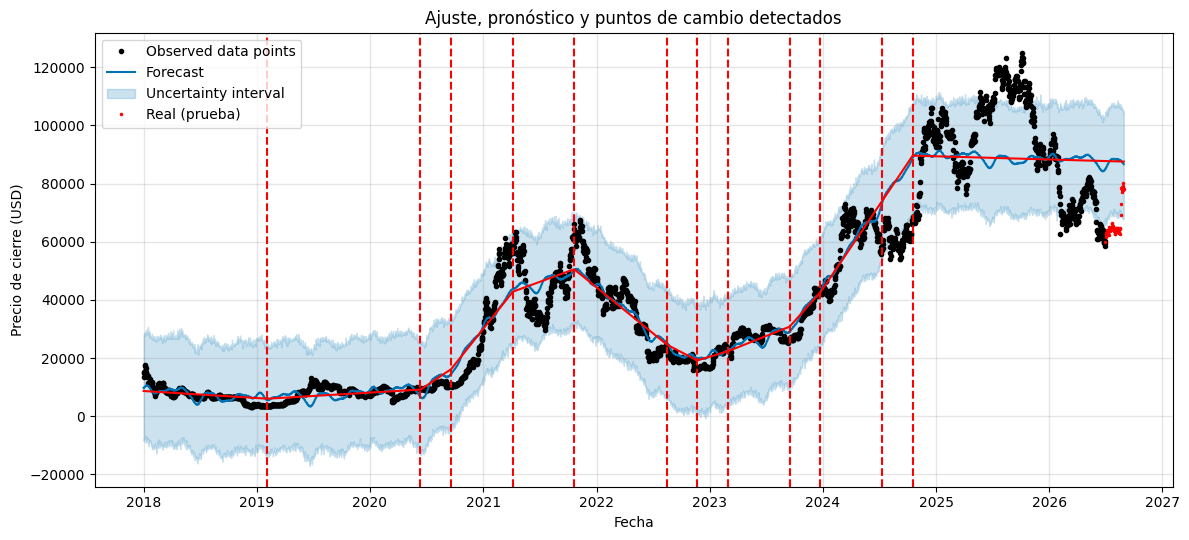

In [37]:
fig = modelo.plot(forecast, figsize=(12, 5.5))
eje = fig.gca()
add_changepoints_to_plot(eje, modelo, forecast)   # línea roja = tendencia; punteadas = changepoints
eje.plot(df_test["ds"], df_test["y"], "r.", markersize=3, label="Real (prueba)")
eje.set_title("Ajuste, pronóstico y puntos de cambio detectados")
eje.set_xlabel("Fecha")
eje.set_ylabel("Precio de cierre (USD)")
eje.legend(loc="upper left")
plt.tight_layout()
plt.show()

### 🔎 ¿Cómo leemos esta gráfica?

- Los **puntos negros** son las observaciones de entrenamiento.
- La **línea azul** es el ajuste del modelo (`yhat`), con su banda de incertidumbre en azul claro.
- Los **puntos rojos pequeños** al final son los valores reales del periodo de prueba, que el modelo
  nunca vio.
- La **línea roja continua** es la tendencia $g(t)$ aislada.
- Las **líneas rojas punteadas verticales** son los puntos de cambio que el modelo consideró
  relevantes: no aparecen los 25 candidatos, solo aquellos con un cambio de pendiente apreciable.

Observa **dónde** caen esas líneas: se concentran en los tramos donde la serie cambió de régimen.
Y observa también que **ninguna aparece cerca del final**, por el límite del 80 %.

### El parámetro `changepoint_prior_scale`

Es el mando que controla **cuánta flexibilidad** se permite a la tendencia. Su valor por defecto es
`0.05`.

| Valor | Efecto sobre la tendencia | Riesgo |
|---|---|---|
| **Bajo** (0.001 - 0.01) | Muy **rígida**, casi una recta. Los cambios de pendiente se penalizan con fuerza. | **Subajuste**: el modelo ignora cambios de régimen reales |
| **Por defecto** (0.05) | Equilibrio entre rigidez y adaptación | — |
| **Alto** (0.5 - 1.0) | Muy **flexible**: la tendencia sigue de cerca cada ondulación | **Sobreajuste**: persigue el ruido y extrapola con una pendiente inestable |

El efecto sobre el **pronóstico** es el que más importa: Prophet proyecta hacia el futuro la
pendiente del último tramo. Con un valor alto, ese último tramo se ajusta a las oscilaciones más
recientes, y basta un repunte casual en las últimas semanas para que el modelo lo extrapole durante
meses.

Comparemos tres valores.

In [38]:
def ajustar_y_evaluar(nombre, **parametros):
    """Entrena un Prophet sobre df_train y lo evalúa sobre df_test.

    Devuelve (modelo_ajustado, forecast, diccionario_de_metricas).
    Los parámetros no indicados toman los valores del modelo base.
    """
    configuracion = dict(
        growth="linear", interval_width=0.95,
        yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
    )
    configuracion.update(parametros)

    m = Prophet(**configuracion)
    m.fit(df_train)

    fc = m.predict(m.make_future_dataframe(periods=len(df_test), freq="D"))
    evaluacion = df_test.merge(fc[["ds", "yhat"]], on="ds", how="left")
    assert evaluacion["yhat"].notna().all(), "Faltan pronósticos para alguna fecha de prueba."

    return m, fc, calcular_metricas(evaluacion["y"], evaluacion["yhat"], nombre)


valores_cps = [0.01, 0.05, 0.5]
modelos_cps = {}

for valor in valores_cps:
    modelos_cps[valor] = ajustar_y_evaluar(f"cps = {valor}", changepoint_prior_scale=valor)
    print(f"Ajustado changepoint_prior_scale = {valor}")

Ajustado changepoint_prior_scale = 0.01
Ajustado changepoint_prior_scale = 0.05
Ajustado changepoint_prior_scale = 0.5


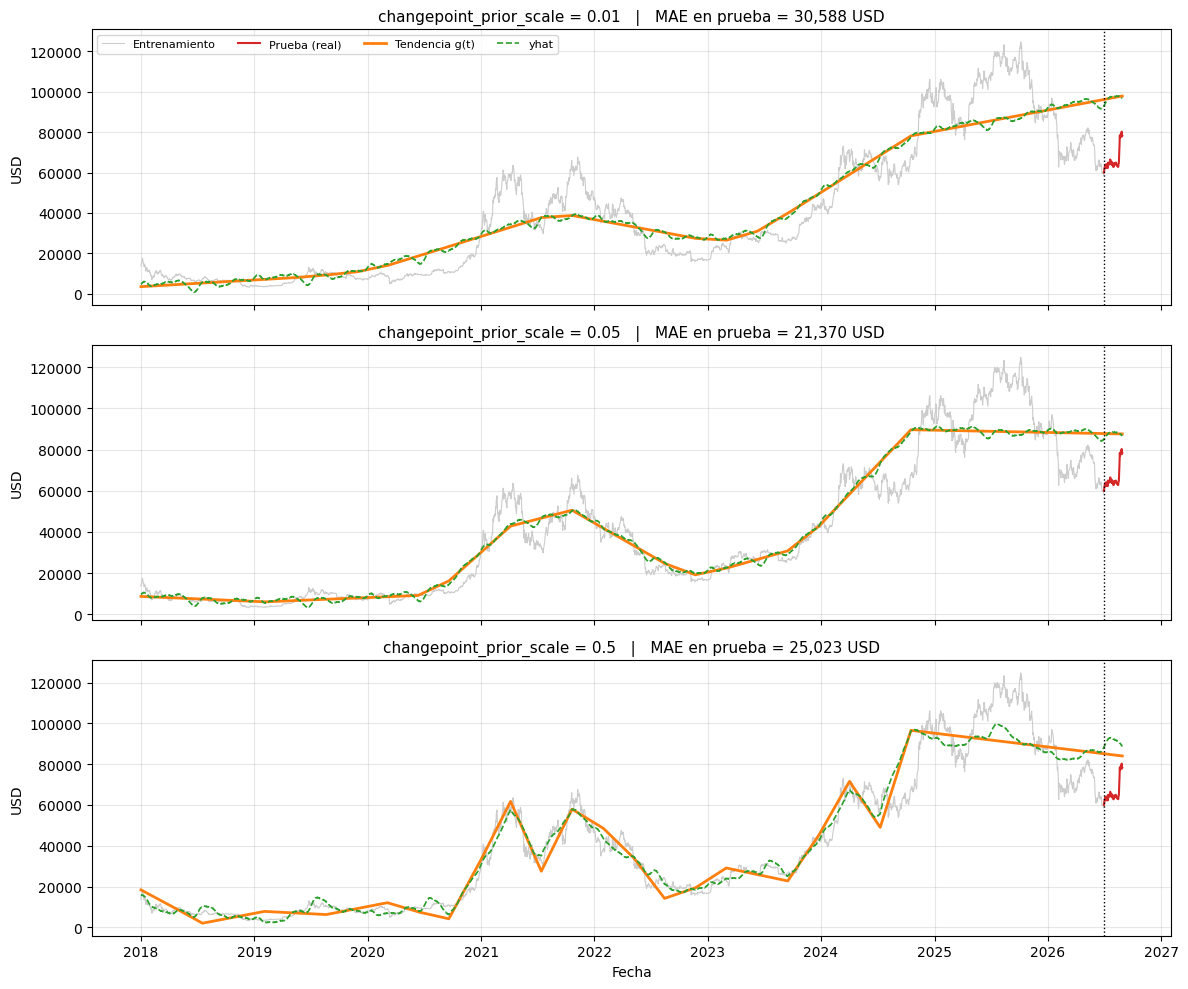

In [39]:
fig, ejes = plt.subplots(len(valores_cps), 1, figsize=(12, 10), sharex=True)

for eje, valor in zip(ejes, valores_cps):
    m_i, fc_i, met_i = modelos_cps[valor]
    eje.plot(df_train["ds"], df_train["y"], color="#cccccc", lw=0.8, label="Entrenamiento")
    eje.plot(df_test["ds"], df_test["y"], color="#d62728", lw=1.5, label="Prueba (real)")
    eje.plot(fc_i["ds"], fc_i["trend"], color="#ff7f0e", lw=2, label="Tendencia g(t)")
    eje.plot(fc_i["ds"], fc_i["yhat"], color="#2ca02c", lw=1.2, ls="--", label="yhat")
    eje.axvline(df_train["ds"].max(), color="black", ls=":", lw=1)
    eje.set_title(f"changepoint_prior_scale = {valor}   |   "
                  f"MAE en prueba = {met_i['MAE']:,.0f} USD", fontsize=11)
    eje.set_ylabel("USD")

ejes[0].legend(loc="upper left", fontsize=8, ncol=4)
ejes[-1].set_xlabel("Fecha")
plt.tight_layout()
plt.show()

In [40]:
tabla_cps = pd.DataFrame([modelos_cps[v][2] for v in valores_cps]).set_index("Modelo")
display(tabla_cps.style.format("{:,.2f}"))

trend_final = {v: modelos_cps[v][1]["trend"].iloc[-1] for v in valores_cps}
resumen_trend = ", ".join(f"**{v}** → {trend_final[v]:,.0f} USD" for v in valores_cps)
mejor_cps = tabla_cps["MAE"].idxmin()
mae_por_cps = ", ".join(f"**{v}** → {modelos_cps[v][2]['MAE']:,.0f} USD" for v in valores_cps)

display(Markdown(f"""
### 🔎 ¿Cómo lo interpretamos?

Mira la **forma de la línea naranja** (la tendencia) en los tres paneles y compárala con la nube gris
del histórico:

- Con **`cps = 0.01`** la tendencia es marcadamente **rígida**: apenas se quiebra, y suaviza los
  cambios de régimen de 2021 y 2022 en lugar de seguirlos. Es la configuración con mayor riesgo de
  **subajuste**.
- Con **`cps = 0.05`** (el valor por defecto) la tendencia reproduce los grandes tramos sin
  perseguir cada oscilación.
- Con **`cps = 0.5`** la tendencia se **pega** mucho más a los datos, quebrándose con frecuencia. El
  ajuste histórico mejora, pero la pendiente con la que el modelo llega al final del entrenamiento
  se vuelve más dependiente del último movimiento local, y esa pendiente es la que se proyecta
  durante los {len(df_test)} días siguientes.

**Los números.** El nivel de tendencia pronosticado para el último día de prueba es:
{resumen_trend}. Y el error sobre el conjunto de prueba: {mae_por_cps}.

En esta ventana, la mejor configuración resultó ser **{mejor_cps}**. Vale la pena detenerse aquí: el
modelo que **peor** describe el histórico puede ser el que **mejor** pronostica. No es una
casualidad ni una paradoja: una tendencia rígida extrapola con más prudencia, y cuando la serie es
poco predecible la prudencia paga.

> ### 💡 Idea clave
> Ajustarse bien al pasado y pronosticar bien el futuro **no son lo mismo**, y con frecuencia entran
> en conflicto. Un modelo más flexible siempre describirá mejor el histórico; eso, por sí solo, no
> es ninguna evidencia de que vaya a pronosticar mejor.
"""))

,MAE,RMSE,MAPE (%),sMAPE (%)
Modelo,,,,
cps = 0.01,"30,588.48","31,035.19",46.96,37.73
cps = 0.05,"21,369.58","22,074.08",33.01,28.02
cps = 0.5,"25,023.43","25,758.00",38.62,31.99



### 🔎 ¿Cómo lo interpretamos?

Mira la **forma de la línea naranja** (la tendencia) en los tres paneles y compárala con la nube gris
del histórico:

- Con **`cps = 0.01`** la tendencia es marcadamente **rígida**: apenas se quiebra, y suaviza los
  cambios de régimen de 2021 y 2022 en lugar de seguirlos. Es la configuración con mayor riesgo de
  **subajuste**.
- Con **`cps = 0.05`** (el valor por defecto) la tendencia reproduce los grandes tramos sin
  perseguir cada oscilación.
- Con **`cps = 0.5`** la tendencia se **pega** mucho más a los datos, quebrándose con frecuencia. El
  ajuste histórico mejora, pero la pendiente con la que el modelo llega al final del entrenamiento
  se vuelve más dependiente del último movimiento local, y esa pendiente es la que se proyecta
  durante los 60 días siguientes.

**Los números.** El nivel de tendencia pronosticado para el último día de prueba es:
**0.01** → 97,902 USD, **0.05** → 87,585 USD, **0.5** → 84,030 USD. Y el error sobre el conjunto de prueba: **0.01** → 30,588 USD, **0.05** → 21,370 USD, **0.5** → 25,023 USD.

En esta ventana, la mejor configuración resultó ser **cps = 0.05**. Vale la pena detenerse aquí: el
modelo que **peor** describe el histórico puede ser el que **mejor** pronostica. No es una
casualidad ni una paradoja: una tendencia rígida extrapola con más prudencia, y cuando la serie es
poco predecible la prudencia paga.

> ### 💡 Idea clave
> Ajustarse bien al pasado y pronosticar bien el futuro **no son lo mismo**, y con frecuencia entran
> en conflicto. Un modelo más flexible siempre describirá mejor el histórico; eso, por sí solo, no
> es ninguna evidencia de que vaya a pronosticar mejor.


---

# 19. Validación cruzada temporal

### 🎯 ¿Qué queremos hacer?
Repetir el ejercicio de "entrenar hasta una fecha y pronosticar los días siguientes" **muchas veces**,
con distintas fechas de corte.

### 🧠 ¿Por qué lo hacemos?
Todo lo medido hasta ahora depende de **una sola ventana de 60 días**. Si esa ventana fue
inusualmente tranquila, las métricas serán optimistas; si fue un desplome, serán pesimistas. En
ninguno de los dos casos sabremos cuál es el desempeño *típico* del modelo.

La validación cruzada temporal —también llamada **origen móvil** (*rolling origin*) o *backtesting*—
resuelve esto simulando cómo habría funcionado el modelo si lo hubiéramos usado en el pasado, una y
otra vez.

### La lógica, dibujada

```text
|<-------------- initial -------------->|<- horizon ->|
[======= entrenamiento =================][ pronóstico ]                    corte 1
                                         ↑
                                      cutoff 1

|<--------- initial + period ---------------->|<- horizon ->|
[======= entrenamiento ======================][ pronóstico ]               corte 2
                                              ↑
                                           cutoff 2

|<--------- initial + 2*period --------------------->|<- horizon ->|
[======= entrenamiento =============================][ pronóstico ]        corte 3
                                                     ↑
                                                  cutoff 3
   ... y así hasta agotar los datos disponibles
```

En cada corte, Prophet **reentrena desde cero** usando solo los datos anteriores al *cutoff* y
pronostica los siguientes `horizon` días. Ninguna predicción usa información posterior a su propio
corte: no hay fuga de información.

### Los tres parámetros

| Parámetro | Qué significa | Nuestro valor |
|---|---|---|
| `initial` | Tamaño del **primer** conjunto de entrenamiento | 1095 días (3 años) |
| `period` | Cuánto **avanza** el corte entre una simulación y la siguiente | 90 días |
| `horizon` | Cuántos días hacia adelante se pronostica en cada corte | 60 días (igual que nuestra prueba) |

Si solo se indica `horizon`, Prophet usa por defecto `initial = 3 × horizon` y
`period = horizon / 2`. Aquí los fijamos explícitamente para que cada corte disponga de al menos tres
años de historia, suficientes para estimar la estacionalidad anual.

### ⚠️ Sobre `parallel="processes"` en Windows

La documentación de Prophet sugiere `parallel="processes"` para acelerar el proceso. En **Windows y
macOS**, sin embargo, Python crea los procesos hijo con el método *spawn*, que vuelve a importar el
módulo principal; dentro de un notebook eso suele terminar en un error de *pickle*, un cuelgue o un
kernel caído.

Por eso dejamos el paralelismo **desactivado por defecto** (`PARALELISMO = None`). Si quieres
acelerar, `"threads"` es la opción intermedia segura en notebooks. Con nuestros datos el proceso
completo tarda menos de un minuto en secuencial.

In [41]:
PARALELISMO = None   # alternativas: "threads" (seguro en notebooks) o "processes" (evitar en Windows)

INITIAL = "1095 days"   # 3 años de historia mínima en cada corte
PERIOD = "90 days"      # el corte avanza un trimestre cada vez
HORIZON = f"{DIAS_PRUEBA} days"

# Antes de lanzarlo, comprobamos cuántas simulaciones va a implicar.
dias_totales = (df_train["ds"].max() - df_train["ds"].min()).days
cortes_estimados = int((dias_totales - 1095 - DIAS_PRUEBA) / 90) + 1

print(f"Días disponibles en entrenamiento : {dias_totales:,}")
print(f"initial={INITIAL}, period={PERIOD}, horizon={HORIZON}")
print(f"Simulaciones estimadas            : ~{cortes_estimados}")
print("\nEntrenando... (cada simulación reentrena el modelo desde cero)")

Días disponibles en entrenamiento : 3,102
initial=1095 days, period=90 days, horizon=60 days
Simulaciones estimadas            : ~22

Entrenando... (cada simulación reentrena el modelo desde cero)


In [42]:
import time

inicio = time.time()
df_cv = cross_validation(
    modelo,
    initial=INITIAL,
    period=PERIOD,
    horizon=HORIZON,
    parallel=PARALELISMO,
)
print(f"Validación cruzada completada en {time.time() - inicio:.0f} segundos.\n")

print(f"Filas totales        : {len(df_cv):,}")
print(f"Cortes (cutoffs)     : {df_cv['cutoff'].nunique()}")
print(f"Predicciones por corte: {len(df_cv) // df_cv['cutoff'].nunique()}")
print(f"\nFechas de corte utilizadas:")
for corte in sorted(df_cv["cutoff"].unique()):
    print(f"  {pd.Timestamp(corte):%Y-%m-%d}")

df_cv.head()

  0%|          | 0/22 [00:00<?, ?it/s]

Validación cruzada completada en 33 segundos.

Filas totales        : 1,320
Cortes (cutoffs)     : 22
Predicciones por corte: 60

Fechas de corte utilizadas:
  2021-02-26
  2021-05-27
  2021-08-25
  2021-11-23
  2022-02-21
  2022-05-22
  2022-08-20
  2022-11-18
  2023-02-16
  2023-05-17
  2023-08-15
  2023-11-13
  2024-02-11
  2024-05-11
  2024-08-09
  2024-11-07
  2025-02-05
  2025-05-06
  2025-08-04
  2025-11-02
  2026-01-31
  2026-05-01


,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2021-02-27,"48,727.92","46,284.75","51,129.04","46,188.45",2021-02-26
1,2021-02-28,"48,781.46","46,240.08","51,128.67","45,137.77",2021-02-26
2,2021-03-01,"48,895.78","46,633.68","51,402.10","49,631.24",2021-02-26
3,2021-03-02,"48,930.61","46,520.00","51,501.40","48,378.99",2021-02-26
4,2021-03-03,"49,056.66","46,611.31","51,243.59","50,538.24",2021-02-26


### 🔎 ¿Cómo leemos `df_cv`?

| Columna | Significado |
|---|---|
| `ds` | Fecha pronosticada |
| `yhat`, `yhat_lower`, `yhat_upper` | Pronóstico e intervalo para esa fecha |
| `y` | Valor **realmente observado** (Prophet lo recupera del histórico para poder comparar) |
| `cutoff` | Fecha de corte de la simulación a la que pertenece la fila |

La diferencia `ds - cutoff` es el **horizonte** de esa predicción: 1 día, 2 días..., hasta 60. Esa
diferencia es la clave de la sección siguiente, porque permite responder a una pregunta que una sola
ventana no puede: **¿cuánto se degrada el pronóstico a medida que miramos más lejos?**

---

# 20. Métricas de la validación cruzada

### 🎯 ¿Qué queremos hacer?
Resumir los errores de todas las simulaciones **agrupándolos por horizonte**.

### 🧠 ¿Por qué lo hacemos?
No es lo mismo equivocarse pronosticando mañana que pronosticando dentro de dos meses. Agrupar por
horizonte convierte el análisis en una respuesta a la pregunta práctica: **¿hasta qué plazo es
razonable usar este modelo?**

`performance_metrics` toma todas las predicciones con el mismo horizonte (de todos los cortes) y
calcula sus métricas.

In [43]:
df_p = performance_metrics(df_cv)

print(f"{len(df_p)} horizontes evaluados. Métricas disponibles: {list(df_p.columns[1:])}\n")
display(df_p.head())
display(df_p.tail())

55 horizontes evaluados. Métricas disponibles: ['mse', 'rmse', 'mae', 'mape', 'mdape', 'smape', 'coverage']



,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,6 days,"179,074,309.33","13,381.86","9,201.45",0.19,0.15,0.18,0.62
1,7 days,"188,371,162.92","13,724.84","9,511.07",0.20,0.15,0.19,0.62
2,8 days,"196,477,882.80","14,017.06","9,677.58",0.20,0.15,0.19,0.62
3,9 days,"207,002,318.86","14,387.58","9,997.07",0.20,0.15,0.20,0.59
4,10 days,"214,797,797.09","14,655.98","10,171.34",0.21,0.15,0.20,0.58


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
50,56 days,"496,540,943.19","22,283.20","17,227.81",0.38,0.26,0.37,0.32
51,57 days,"510,069,351.19","22,584.71","17,525.71",0.38,0.27,0.37,0.31
52,58 days,"520,573,392.38","22,816.08","17,755.77",0.38,0.28,0.38,0.30
53,59 days,"528,805,576.44","22,995.77","17,961.24",0.39,0.28,0.38,0.30
54,60 days,"534,840,670.76","23,126.62","18,145.80",0.39,0.28,0.39,0.30


### Las métricas, una por una

| Métrica | Nombre completo | Cómo se lee |
|---|---|---|
| **MSE** | Error cuadrático medio | Promedio de los errores al cuadrado. Está en **dólares al cuadrado**, así que no es interpretable directamente; se usa como paso intermedio |
| **RMSE** | Raíz del error cuadrático medio | La raíz del anterior: vuelve a dólares. **Penaliza los errores grandes** |
| **MAE** | Error absoluto medio | Error promedio en dólares. El más fácil de explicar |
| **MAPE** | Error porcentual absoluto medio | Error medio como porcentaje del valor real. Independiente de la escala |
| **MDAPE** | **Mediana** del error porcentual absoluto | Como el MAPE pero con la mediana: **mucho más robusto a los días atípicos**. Si MDAPE ≪ MAPE, unos pocos días están inflando el promedio |
| **SMAPE** | Error porcentual absoluto simétrico | Variante del MAPE que trata igual sobreestimar y subestimar |
| **coverage** | Cobertura del intervalo | Proporción de valores reales que cayeron dentro de la banda. Con `interval_width=0.95` debería rondar **0,95** |

### La visualización

`plot_cross_validation_metric` dibuja, para la métrica elegida, el error de **cada predicción
individual** frente a su horizonte, junto con una media móvil.

> **Nota de compatibilidad.** En Prophet 1.3.0 esta función utiliza internamente `Series.view()`,
> un método que **pandas eliminó en la versión 3.0**. Si tu entorno combina ambas versiones, la
> llamada falla con `AttributeError: 'Series' object has no attribute 'view'`. No es un error de tu
> código. La celda siguiente intenta primero la función oficial y, si falla, construye exactamente
> la misma gráfica a partir de `df_cv` y `df_p`. Así el notebook funciona en cualquier combinación
> de versiones.

plot_cross_validation_metric no está disponible ('Series' object has no attribute 'view').
Reconstruimos la misma gráfica manualmente.



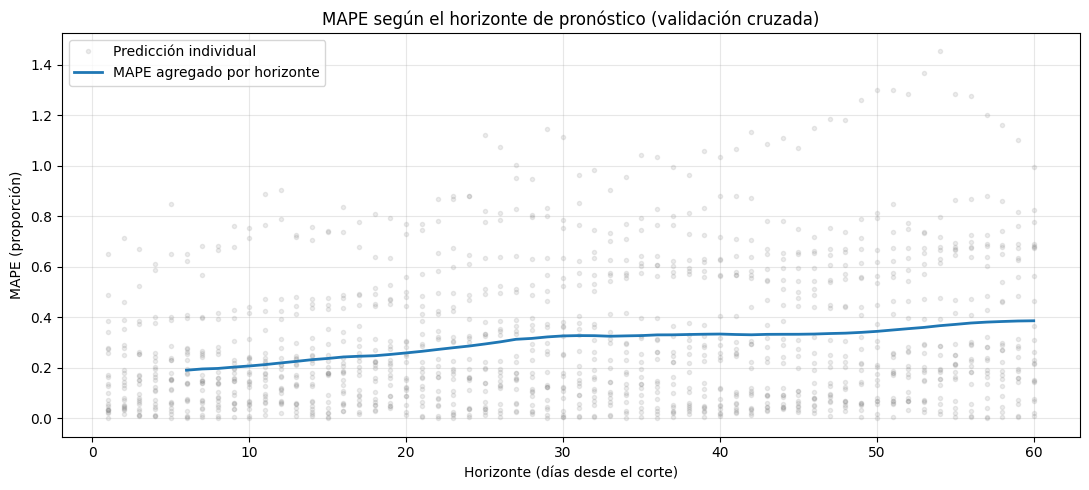

In [53]:
try:
    fig = plot_cross_validation_metric(df_cv, metric="mape", figsize=(11, 5))
    eje = fig.gca()
except AttributeError as error:
    # Incompatibilidad conocida entre Prophet 1.3.0 y pandas >= 3.0 (Series.view eliminado).
    print(f"plot_cross_validation_metric no está disponible ({error}).")
    print("Reconstruimos la misma gráfica manualmente.\n")
    plt.close("all")   # descartamos la figura a medias que dejó la función al fallar

    horizonte_dias = (df_cv["ds"] - df_cv["cutoff"]).dt.days          # horizonte de cada predicción
    error_pct = (df_cv["y"] - df_cv["yhat"]).abs() / df_cv["y"]       # error porcentual absoluto

    fig, eje = plt.subplots(figsize=(11, 5))
    eje.plot(horizonte_dias, error_pct, ".", alpha=0.15, color="gray",
             label="Predicción individual")
    eje.plot(df_p["horizon"].dt.days, df_p["mape"], "-", color="#1f77b4", lw=2,
             label="MAPE agregado por horizonte")
    eje.legend()

eje.set_title("MAPE según el horizonte de pronóstico (validación cruzada)")
eje.set_xlabel("Horizonte (días desde el corte)")
eje.set_ylabel("MAPE (proporción)")
plt.tight_layout()
plt.show()

In [45]:
primer_dia = df_p.iloc[0]
ultimo_dia = df_p.iloc[-1]
h_corto = int(primer_dia["horizon"].days)     # horizonte más corto que resume performance_metrics
h_largo = int(ultimo_dia["horizon"].days)
mape_1 = primer_dia["mape"] * 100
mape_60 = ultimo_dia["mape"] * 100
cobertura_media = df_p["coverage"].mean() * 100
ratio_mdape = ultimo_dia["mdape"] * 100

if ratio_mdape < mape_60 * 0.8:
    lectura_mdape = ("Que el MDAPE sea bastante menor indica que unos pocos cortes muy malos "
                     "(probablemente los que coincidieron con caídas bruscas) están inflando el "
                     "promedio: el día *típico* es mejor de lo que sugiere el MAPE.")
else:
    lectura_mdape = ("Su cercanía indica que los errores están repartidos de forma bastante "
                     "homogénea entre los cortes.")

if cobertura_media < 90:
    lectura_cobertura = ("Está por debajo de lo prometido: el modelo es **más confiado de lo que "
                         "debería**, algo habitual en series con volatilidad cambiante.")
else:
    lectura_cobertura = ("Es coherente con lo prometido, aunque conviene recordar que esa banda se "
                         "calibró con la volatilidad del pasado.")

display(Markdown(f"""
### 🔎 ¿Cómo lo interpretamos?

**La gráfica.** Cada punto gris es el error porcentual de **una predicción concreta** (un corte, un
día); la línea azul es el error agregado por horizonte. El eje horizontal llega hasta
{h_largo} días.

Un detalle sobre la tabla: `performance_metrics` **no** empieza en el día 1. Por defecto agrega las
predicciones en una ventana móvil del 10 % de los datos (`rolling_window=0.1`), de modo que el
primer horizonte resumido es el de **{h_corto} días**. Si quieres el detalle día a día sin
suavizado, usa `performance_metrics(df_cv, rolling_window=0)`.

**El patrón fundamental: el error crece con el horizonte.**

- A **{h_corto} días** de distancia, el MAPE ronda el **{mape_1:.1f} %**.
- A **{h_largo} días**, sube hasta el **{mape_60:.1f} %**,
  aproximadamente **{mape_60 / max(mape_1, 1e-9):.1f} veces más**.

Que el error crezca con el horizonte es lo esperable: a medida que nos alejamos del corte se
acumulan dos fuentes de error, la incertidumbre sobre **dónde estará la tendencia** y la
acumulación de **shocks impredecibles**. Como el precio se parece a un paseo aleatorio, la
incertidumbre crece aproximadamente con la **raíz del horizonte**.

Ahora bien, fíjate en el nivel de partida: **ya en el horizonte más corto el error es del
{mape_1:.1f} %**. No estamos ante un modelo preciso que se degrada, sino ante uno que **nunca llega
a ser preciso**. La razón es que estos cortes abarcan 2021 y 2022, años en los que la tendencia
estimada y la realidad divergieron con fuerza.

**La dispersión importa tanto como la media.** La nube de puntos grises se abre a la derecha: a 60
días hay predicciones casi perfectas y predicciones pésimas. Ese abanico dice que el error a largo
plazo **no solo es mayor, sino mucho menos previsible**.

**MAPE frente a MDAPE.** En el horizonte más largo, el MAPE es del **{mape_60:.1f} %** y el MDAPE del
**{ratio_mdape:.1f} %**. {lectura_mdape}

**Cobertura.** El intervalo del 95 % capturó en promedio el **{cobertura_media:.0f} %** de los
valores reales. {lectura_cobertura}

> ### 💡 Idea clave
> Un modelo de *forecasting* no tiene "una" precisión: tiene **una precisión por horizonte**. La
> pregunta útil no es "¿es bueno el modelo?" sino **"¿hasta qué plazo es suficientemente bueno para
> la decisión que tengo que tomar?"**.
"""))


### 🔎 ¿Cómo lo interpretamos?

**La gráfica.** Cada punto gris es el error porcentual de **una predicción concreta** (un corte, un
día); la línea azul es el error agregado por horizonte. El eje horizontal llega hasta
60 días.

Un detalle sobre la tabla: `performance_metrics` **no** empieza en el día 1. Por defecto agrega las
predicciones en una ventana móvil del 10 % de los datos (`rolling_window=0.1`), de modo que el
primer horizonte resumido es el de **6 días**. Si quieres el detalle día a día sin
suavizado, usa `performance_metrics(df_cv, rolling_window=0)`.

**El patrón fundamental: el error crece con el horizonte.**

- A **6 días** de distancia, el MAPE ronda el **19.1 %**.
- A **60 días**, sube hasta el **38.6 %**,
  aproximadamente **2.0 veces más**.

Que el error crezca con el horizonte es lo esperable: a medida que nos alejamos del corte se
acumulan dos fuentes de error, la incertidumbre sobre **dónde estará la tendencia** y la
acumulación de **shocks impredecibles**. Como el precio se parece a un paseo aleatorio, la
incertidumbre crece aproximadamente con la **raíz del horizonte**.

Ahora bien, fíjate en el nivel de partida: **ya en el horizonte más corto el error es del
19.1 %**. No estamos ante un modelo preciso que se degrada, sino ante uno que **nunca llega
a ser preciso**. La razón es que estos cortes abarcan 2021 y 2022, años en los que la tendencia
estimada y la realidad divergieron con fuerza.

**La dispersión importa tanto como la media.** La nube de puntos grises se abre a la derecha: a 60
días hay predicciones casi perfectas y predicciones pésimas. Ese abanico dice que el error a largo
plazo **no solo es mayor, sino mucho menos previsible**.

**MAPE frente a MDAPE.** En el horizonte más largo, el MAPE es del **38.6 %** y el MDAPE del
**28.3 %**. Que el MDAPE sea bastante menor indica que unos pocos cortes muy malos (probablemente los que coincidieron con caídas bruscas) están inflando el promedio: el día *típico* es mejor de lo que sugiere el MAPE.

**Cobertura.** El intervalo del 95 % capturó en promedio el **41 %** de los
valores reales. Está por debajo de lo prometido: el modelo es **más confiado de lo que debería**, algo habitual en series con volatilidad cambiante.

> ### 💡 Idea clave
> Un modelo de *forecasting* no tiene "una" precisión: tiene **una precisión por horizonte**. La
> pregunta útil no es "¿es bueno el modelo?" sino **"¿hasta qué plazo es suficientemente bueno para
> la decisión que tengo que tomar?"**.


---

# 21. Ajuste de hiperparámetros

### 🎯 ¿Qué queremos hacer?
Conocer los tres parámetros que más influyen en un modelo Prophet y ver su efecto.

### 🧠 ¿Por qué lo hacemos?
Los **parámetros** de un modelo se aprenden de los datos (las pendientes, las amplitudes
estacionales). Los **hiperparámetros** los elegimos nosotros **antes** de entrenar, y determinan qué
puede y qué no puede aprender el modelo. Elegirlos bien importa tanto como elegir el modelo.

### `changepoint_prior_scale` (por defecto: 0.05)

Controla **qué tan flexible puede ser la tendencia**, como vimos en la sección 18. Es, con
diferencia, el hiperparámetro más influyente en Prophet. Rango razonable de exploración:
**0.001 a 0.5**.

- **Bajar**lo → tendencia más rígida → menos reacción a los cambios de régimen → riesgo de
  **subajuste**.
- **Subir**lo → tendencia más flexible → se adapta a cada ondulación → riesgo de **sobreajuste** y,
  sobre todo, extrapolaciones agresivas.

### `seasonality_prior_scale` (por defecto: 10.0)

Controla **la flexibilidad de los efectos estacionales**: cuánta amplitud se le permite a las curvas
semanal y anual. Rango razonable: **0.01 a 10**.

- Un valor **bajo** encoge las estacionalidades hacia cero: el modelo casi las ignora.
- Un valor **alto** les permite tomar amplitudes grandes.

Cuando la estacionalidad es débil o dudosa —nuestro caso—, un valor bajo actúa como regularización y
evita que el modelo invente patrones semanales a partir del ruido.

### `seasonality_mode`: `"additive"` frente a `"multiplicative"`

Esta elección responde a una pregunta muy concreta: **¿el efecto estacional es una cantidad fija o
una proporción del nivel?**

| Modo | Fórmula | Cuándo usarlo |
|---|---|---|
| `"additive"` (por defecto) | $y = g(t) + s(t)$ | El efecto estacional tiene **tamaño constante**: "los sábados se venden 50 unidades más", tanto en un año flojo como en uno bueno |
| `"multiplicative"` | $y = g(t) \times (1 + s(t))$ | El efecto estacional es **proporcional al nivel**: "los sábados se vende un 10 % más", así que crece cuando crece el negocio |

La pista visual está en la gráfica de la serie: si las oscilaciones **se agrandan** cuando el nivel
sube (un abanico que se abre), el modo multiplicativo suele ser el adecuado. En nuestra serie el
precio pasó de unos 4.000 a más de 70.000 USD, y las oscilaciones crecieron con él: es un candidato
natural para el modo multiplicativo.

> ⚠️ **No haremos una búsqueda exhaustiva.** Probar cientos de combinaciones tiene dos costos: es
> lento y, sobre todo, aumenta la probabilidad de encontrar una configuración que funciona bien
> **por casualidad** en nuestro conjunto de prueba. Compararemos unas pocas configuraciones
> justificadas.

In [46]:
configuraciones = {
    "Base (cps=0.05, aditivo)": {},
    "Tendencia rígida (cps=0.01)": {"changepoint_prior_scale": 0.01},
    "Tendencia flexible (cps=0.5)": {"changepoint_prior_scale": 0.5},
    "Estacionalidad multiplicativa": {"seasonality_mode": "multiplicative"},
    "Estacionalidad regularizada (sps=0.1)": {"seasonality_prior_scale": 0.1},
}

resultados = []
for nombre, parametros in configuraciones.items():
    _, _, metricas = ajustar_y_evaluar(nombre, **parametros)
    resultados.append(metricas)
    print(f"  ✓ {nombre}")

tabla_hiper = pd.DataFrame(resultados).set_index("Modelo").sort_values("MAE")
display(tabla_hiper.style.format("{:,.2f}").background_gradient(cmap="RdYlGn_r", axis=0))

  ✓ Base (cps=0.05, aditivo)
  ✓ Tendencia rígida (cps=0.01)
  ✓ Tendencia flexible (cps=0.5)
  ✓ Estacionalidad multiplicativa
  ✓ Estacionalidad regularizada (sps=0.1)


,MAE,RMSE,MAPE (%),sMAPE (%)
Modelo,,,,
Estacionalidad regularizada (sps=0.1),"21,297.26","22,004.63",32.91,27.94
"Base (cps=0.05, aditivo)","21,369.58","22,074.08",33.01,28.02
Tendencia flexible (cps=0.5),"25,023.43","25,758.00",38.62,31.99
Estacionalidad multiplicativa,"26,025.91","26,774.46",40.10,33.02
Tendencia rígida (cps=0.01),"30,588.48","31,035.19",46.96,37.73


In [47]:
mejor_config = tabla_hiper.index[0]
peor_config = tabla_hiper.index[-1]
rango_mae = tabla_hiper["MAE"].max() - tabla_hiper["MAE"].min()
dispersion = 100 * rango_mae / tabla_hiper["MAE"].min()

display(Markdown(f"""
### 🔎 ¿Cómo lo interpretamos?

En esta ventana de prueba, la mejor configuración fue **{mejor_config}**
(MAE = {tabla_hiper['MAE'].iloc[0]:,.0f} USD) y la peor, **{peor_config}**
(MAE = {tabla_hiper['MAE'].iloc[-1]:,.0f} USD). La diferencia entre ambas es de
**{rango_mae:,.0f} USD**, un **{dispersion:.0f} %** sobre el mejor resultado.

Ese número es el mensaje de la sección: **la elección de hiperparámetros cambia el resultado tanto
como cambiarían los datos**. No es un detalle de afinación.

Compara ahora ese resultado con lo que sugería la teoría. Habíamos razonado que la estacionalidad
**multiplicativa** era el candidato natural, porque las oscilaciones crecen con el nivel del precio.
Mira en qué posición quedó en la tabla. Cuando el argumento teórico y la evidencia empírica no
coinciden, lo interesante no es elegir a ciegas uno de los dos, sino preguntarse **por qué**. Si el
modo multiplicativo quedó por detrás de lo que sugería la teoría, una explicación plausible es que
en ese modo todo el componente estacional se multiplica por el nivel de la tendencia: cuando la
tendencia ya apunta en la dirección equivocada, el error no solo se mantiene, sino que **escala con
ella**.

> ### ⚠️ Una trampa metodológica que acabamos de rozar
>
> Hemos elegido la mejor configuración **mirando el conjunto de prueba**. Eso convierte a la prueba
> en parte del proceso de ajuste y, a partir de ese momento, sus métricas **ya no son una estimación
> honesta** del desempeño futuro: hemos "gastado" el conjunto de prueba.
>
> Lo correcto es una de estas dos opciones:
>
> 1. Dividir en **tres** bloques cronológicos: entrenamiento → **validación** (para elegir
>    hiperparámetros) → prueba (que se toca **una sola vez**, al final).
> 2. Elegir los hiperparámetros por **validación cruzada temporal** sobre el conjunto de
>    entrenamiento (la sección 19), y reservar la prueba para la evaluación final.
>
> Aquí hemos usado la prueba con fines didácticos, para que el efecto de cada parámetro se vea con
> una única tabla. En un trabajo real, esta tabla se construye sobre validación, no sobre prueba.

> ### 💡 Idea clave
> Cada vez que miras el conjunto de prueba para tomar una decisión, lo contaminas un poco. Un
> conjunto de prueba mirado muchas veces deja de ser un conjunto de prueba.
"""))


### 🔎 ¿Cómo lo interpretamos?

En esta ventana de prueba, la mejor configuración fue **Estacionalidad regularizada (sps=0.1)**
(MAE = 21,297 USD) y la peor, **Tendencia rígida (cps=0.01)**
(MAE = 30,588 USD). La diferencia entre ambas es de
**9,291 USD**, un **44 %** sobre el mejor resultado.

Ese número es el mensaje de la sección: **la elección de hiperparámetros cambia el resultado tanto
como cambiarían los datos**. No es un detalle de afinación.

Compara ahora ese resultado con lo que sugería la teoría. Habíamos razonado que la estacionalidad
**multiplicativa** era el candidato natural, porque las oscilaciones crecen con el nivel del precio.
Mira en qué posición quedó en la tabla. Cuando el argumento teórico y la evidencia empírica no
coinciden, lo interesante no es elegir a ciegas uno de los dos, sino preguntarse **por qué**. Si el
modo multiplicativo quedó por detrás de lo que sugería la teoría, una explicación plausible es que
en ese modo todo el componente estacional se multiplica por el nivel de la tendencia: cuando la
tendencia ya apunta en la dirección equivocada, el error no solo se mantiene, sino que **escala con
ella**.

> ### ⚠️ Una trampa metodológica que acabamos de rozar
>
> Hemos elegido la mejor configuración **mirando el conjunto de prueba**. Eso convierte a la prueba
> en parte del proceso de ajuste y, a partir de ese momento, sus métricas **ya no son una estimación
> honesta** del desempeño futuro: hemos "gastado" el conjunto de prueba.
>
> Lo correcto es una de estas dos opciones:
>
> 1. Dividir en **tres** bloques cronológicos: entrenamiento → **validación** (para elegir
>    hiperparámetros) → prueba (que se toca **una sola vez**, al final).
> 2. Elegir los hiperparámetros por **validación cruzada temporal** sobre el conjunto de
>    entrenamiento (la sección 19), y reservar la prueba para la evaluación final.
>
> Aquí hemos usado la prueba con fines didácticos, para que el efecto de cada parámetro se vea con
> una única tabla. En un trabajo real, esta tabla se construye sobre validación, no sobre prueba.

> ### 💡 Idea clave
> Cada vez que miras el conjunto de prueba para tomar una decisión, lo contaminas un poco. Un
> conjunto de prueba mirado muchas veces deja de ser un conjunto de prueba.


---

# 22. Análisis de residuos

### 🎯 ¿Qué queremos hacer?
Estudiar lo que el modelo **no** logró explicar:

$$
\text{residuo}_t = y_t - \hat{y}_t
$$

### 🧠 ¿Por qué lo hacemos?
Las métricas resumen el error en un número; los residuos muestran **su estructura**. Y ahí está la
información útil: si en el error sobra algún patrón, ese patrón era información que el modelo debió
haber capturado y no capturó.

### ¿Qué esperaríamos idealmente?

| Propiedad | Qué significaría | Cómo lo miramos |
|---|---|---|
| **Media cercana a cero** | El modelo no está sesgado sistemáticamente hacia arriba o hacia abajo | Media de los residuos |
| **Sin estructura temporal** | No quedan tendencias ni ciclos sin modelar | Gráfica de residuos contra el tiempo |
| **Sin autocorrelación** | El error de hoy no permite anticipar el de mañana | Función de autocorrelación (ACF) |
| **Varianza constante** | La precisión no depende del momento | Dispersión a lo largo del tiempo |
| **Distribución simétrica** | Errores por exceso y por defecto de tamaño parecido | Histograma |

Analizamos por separado los residuos **dentro de la muestra** (entrenamiento: miden la calidad del
ajuste) y los residuos **fuera de la muestra** (prueba: miden la calidad del pronóstico real).

In [48]:
# Residuos dentro de la muestra (ajuste sobre el entrenamiento)
ajuste_train = df_train.merge(forecast[["ds", "yhat"]], on="ds", how="left")
residuos_train = (ajuste_train["y"] - ajuste_train["yhat"]).to_numpy()

# Residuos fuera de la muestra (pronóstico real sobre la prueba)
residuos_test = comparacion["error"].to_numpy()

resumen_residuos = pd.DataFrame({
    "Entrenamiento": [len(residuos_train), residuos_train.mean(), residuos_train.std(),
                      np.median(residuos_train), residuos_train.min(), residuos_train.max()],
    "Prueba": [len(residuos_test), residuos_test.mean(), residuos_test.std(),
               np.median(residuos_test), residuos_test.min(), residuos_test.max()],
}, index=["n", "Media", "Desv. estándar", "Mediana", "Mínimo", "Máximo"])
display(resumen_residuos.style.format("{:,.2f}"))

,Entrenamiento,Prueba
n,"3,103.00",60.00
Media,1.76,"-21,369.58"
Desv. estándar,"9,512.40","5,532.27"
Mediana,-513.81,"-23,454.23"
Mínimo,"-27,389.73","-25,569.26"
Máximo,"37,605.23","-6,699.95"


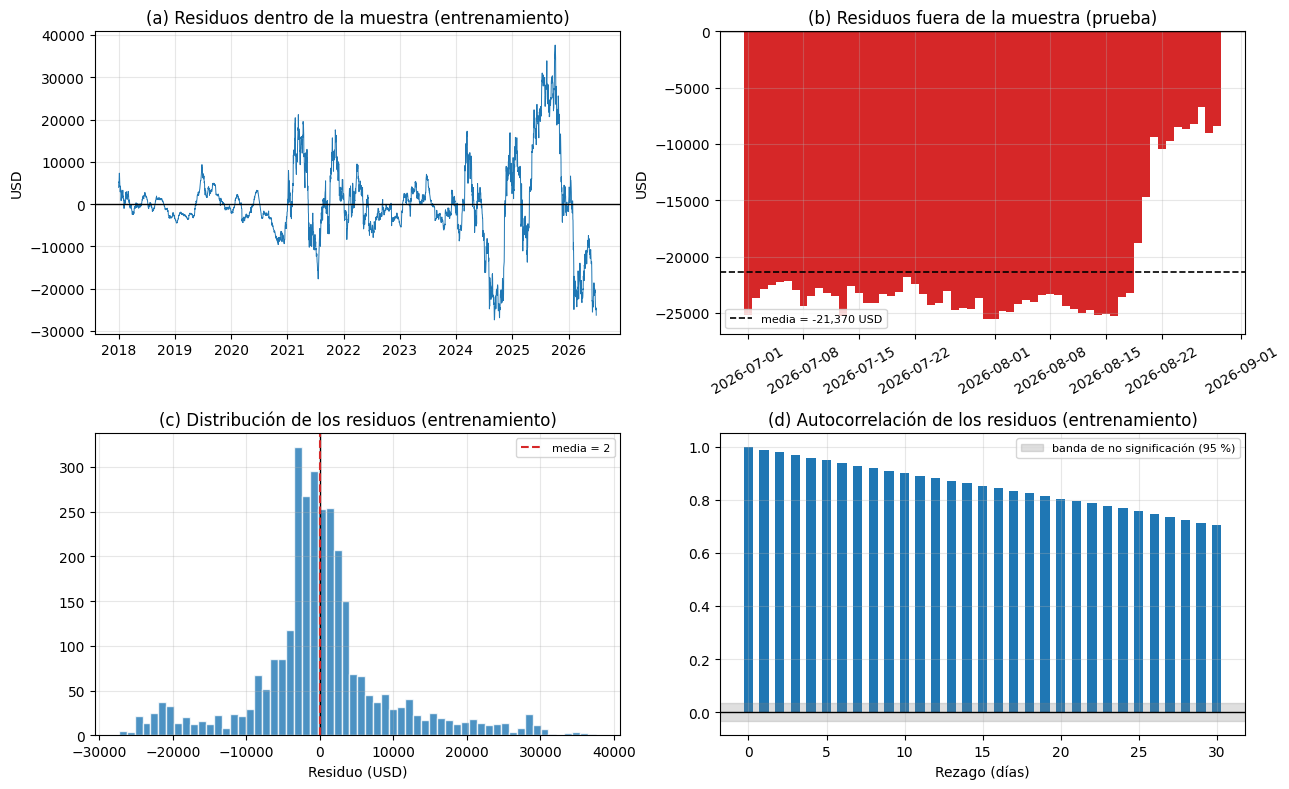

In [49]:
def autocorrelacion(serie, num_rezagos=30):
    """Función de autocorrelación (ACF) calculada con NumPy, sin dependencias extra."""
    x = np.asarray(serie, dtype=float)
    x = x - x.mean()
    denominador = np.sum(x ** 2)
    n = len(x)
    return np.array([np.sum(x[k:] * x[:n - k]) / denominador for k in range(num_rezagos + 1)])


fig, ejes = plt.subplots(2, 2, figsize=(13, 8))

# (a) Residuos de entrenamiento en el tiempo
ejes[0, 0].plot(ajuste_train["ds"], residuos_train, lw=0.7, color="#1f77b4")
ejes[0, 0].axhline(0, color="black", lw=1)
ejes[0, 0].set_title("(a) Residuos dentro de la muestra (entrenamiento)")
ejes[0, 0].set_ylabel("USD")

# (b) Residuos de prueba en el tiempo
ejes[0, 1].bar(comparacion["ds"], residuos_test,
               color=np.where(residuos_test >= 0, "#2ca02c", "#d62728"), width=1.0)
ejes[0, 1].axhline(0, color="black", lw=1)
ejes[0, 1].axhline(residuos_test.mean(), color="black", ls="--", lw=1.2,
                   label=f"media = {residuos_test.mean():,.0f} USD")
ejes[0, 1].set_title("(b) Residuos fuera de la muestra (prueba)")
ejes[0, 1].set_ylabel("USD")
ejes[0, 1].legend(fontsize=8)
ejes[0, 1].tick_params(axis="x", rotation=30)

# (c) Histograma de los residuos de entrenamiento
ejes[1, 0].hist(residuos_train, bins=60, color="#1f77b4", alpha=0.8, edgecolor="white")
ejes[1, 0].axvline(0, color="black", lw=1)
ejes[1, 0].axvline(residuos_train.mean(), color="#d62728", ls="--", lw=1.5,
                   label=f"media = {residuos_train.mean():,.0f}")
ejes[1, 0].set_title("(c) Distribución de los residuos (entrenamiento)")
ejes[1, 0].set_xlabel("Residuo (USD)")
ejes[1, 0].legend(fontsize=8)

# (d) Autocorrelación de los residuos de entrenamiento
acf_valores = autocorrelacion(residuos_train, num_rezagos=30)
banda = 1.96 / np.sqrt(len(residuos_train))
ejes[1, 1].bar(range(len(acf_valores)), acf_valores, color="#1f77b4", width=0.6)
ejes[1, 1].axhline(0, color="black", lw=1)
ejes[1, 1].axhspan(-banda, banda, color="gray", alpha=0.25,
                   label="banda de no significación (95 %)")
ejes[1, 1].set_title("(d) Autocorrelación de los residuos (entrenamiento)")
ejes[1, 1].set_xlabel("Rezago (días)")
ejes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [50]:
acf_1 = acf_valores[1]
media_train = residuos_train.mean()

# ¿Crece la dispersión del error con el nivel del precio? Lo medimos por año.
dispersion_anual = (
    ajuste_train.assign(residuo=residuos_train, anio=ajuste_train["ds"].dt.year)
    .groupby("anio")
    .apply(lambda g: pd.Series({"desv_residuo": g["residuo"].std(),
                                "precio_medio": g["y"].mean()}), include_groups=False)
)
dispersion_anual["error_relativo_%"] = (
    100 * dispersion_anual["desv_residuo"] / dispersion_anual["precio_medio"]
)
print("Dispersión del residuo por año:")
print(dispersion_anual.round(1).to_string())

anio_disperso = dispersion_anual["desv_residuo"].idxmax()
anio_estable = dispersion_anual["desv_residuo"].idxmin()
desv_max = dispersion_anual["desv_residuo"].max()
desv_min = dispersion_anual["desv_residuo"].min()
anio_ini, anio_fin = dispersion_anual.index[0], dispersion_anual.index[-1]
rel_ini = dispersion_anual.loc[anio_ini, "error_relativo_%"]
rel_fin = dispersion_anual.loc[anio_fin, "error_relativo_%"]

media_test = residuos_test.mean()
positivos_test = 100 * (residuos_test > 0).mean()
asimetria = float(pd.Series(residuos_train).skew())
curtosis = float(pd.Series(residuos_train).kurtosis())

if curtosis > 1:
    lectura_colas = ("Una curtosis claramente superior a 0 indica **colas pesadas**: hay más errores "
                     "extremos de los que tendría una distribución normal.")
elif curtosis > 0:
    lectura_colas = ("La curtosis es algo mayor que 0, lo que sugiere colas **ligeramente** más "
                     "pesadas que las de una distribución normal.")
else:
    lectura_colas = ("La curtosis no supera la de una distribución normal, así que no hay indicios "
                     "de colas especialmente pesadas.")

if abs(media_test) < residuos_test.std() / 4:
    lectura_sesgo = "no hay un sesgo marcado en el periodo de prueba"
elif media_test < 0:
    lectura_sesgo = "el modelo sobreestimó de forma sistemática durante el periodo de prueba"
else:
    lectura_sesgo = "el modelo subestimó de forma sistemática durante el periodo de prueba"

display(Markdown(f"""
### 🔎 ¿Cómo lo interpretamos?

**(a) Residuos de entrenamiento en el tiempo.** Su media es **{media_train:,.1f} USD**, es decir,
prácticamente cero: es lo esperado, porque el ajuste centra el error dentro de la muestra.

Lo revelador está en la **dispersión**, no en el centro. Mira la tabla por años que imprime la
celda: la desviación típica del residuo va de **{desv_min:,.0f} USD** en {anio_estable} a
**{desv_max:,.0f} USD** en {anio_disperso}: **{desv_max / desv_min:.1f} veces más**. Eso es **heterocedasticidad**
—varianza del error no constante— y viola uno de los supuestos ideales.

Fíjate, sin embargo, en que **no es una simple cuestión de escala**. Si el error creciera
proporcionalmente al precio, la última columna (el error relativo al precio medio del año) sería
aproximadamente constante; en cambio pasa del **{rel_ini:.0f} %** en {anio_ini} al
**{rel_fin:.0f} %** en {anio_fin}. Lo que ocurre es que la dispersión del error depende del
**régimen** en el que se encuentre la serie: se dispara en los años de movimientos violentos
({anio_disperso}) y se reduce en los tramos más ordenados ({anio_estable}).

Esto tiene dos consecuencias prácticas. La primera es que, cuando el error escala con el nivel,
modelar el **logaritmo** del precio (o usar estacionalidad multiplicativa) suele ayudar. La segunda
es más incómoda: un intervalo de incertidumbre calibrado con la volatilidad **media** del histórico
será demasiado ancho en los periodos tranquilos y demasiado estrecho justo cuando más falta hace.

**(b) Residuos de prueba.** La media es **{media_test:,.0f} USD** y el **{positivos_test:.0f} %** de
los días tiene residuo positivo. En conjunto, {lectura_sesgo}. Si las barras del mismo color se
agrupan en rachas largas en lugar de alternarse, el error **no es ruido independiente**: es una
desviación persistente, típica de un modelo cuya tendencia apunta en la dirección equivocada.

**(c) Histograma.** La distribución está centrada cerca de cero, con asimetría
**{asimetria:.2f}** y curtosis **{curtosis:.2f}** (en una distribución normal ambas valdrían 0).
{lectura_colas}

> ⚠️ **No afirmes normalidad mirando un histograma.** Una campana a ojo no demuestra nada: la forma
> depende del número de barras elegido, y el ojo humano es muy malo juzgando colas. Si la normalidad
> importa para tu análisis, usa un **gráfico Q-Q** y una prueba formal (Shapiro-Wilk,
> Jarque-Bera). Aquí nos limitamos a describir la forma.

**(d) Autocorrelación.** Este es el panel más informativo, y el resultado es contundente: la
autocorrelación en el rezago 1 es **{acf_1:.2f}**, muy por encima de la banda de no significación
(±{banda:.3f}), y decae **muy lentamente**.

Esto significa que **el error de hoy predice el error de mañana**. Si el modelo se quedó corto hoy,
se quedará corto mañana. Dicho de otro modo: **queda una cantidad enorme de estructura sin
modelar**. El precio es fuertemente persistente y Prophet, con tendencia y estacionalidad, no
captura esa persistencia de corto plazo; un modelo ARIMA, que modela explícitamente la dependencia
entre observaciones cercanas, sí lo haría.

> ### 💡 Idea clave
> **Los residuos son el diagnóstico más honesto de un modelo.** Si en ellos queda estructura —
> autocorrelación, varianza creciente, rachas de signo—, esa estructura es información disponible
> que el modelo desperdició.
"""))

Dispersión del residuo por año:
      desv_residuo  precio_medio  error_relativo_%
anio                                              
2018      1,859.80      7,572.30             24.60
2019      3,135.40      7,395.20             42.40
2020      3,290.10     11,116.40             29.60
2021      8,987.90     47,436.90             18.90
2022      3,462.00     28,197.80             12.30
2023      2,918.50     28,859.40             10.10
2024     11,933.50     65,964.10             18.10
2025     12,436.20    101,641.90             12.20
2026      8,352.50     74,059.40             11.30



### 🔎 ¿Cómo lo interpretamos?

**(a) Residuos de entrenamiento en el tiempo.** Su media es **1.8 USD**, es decir,
prácticamente cero: es lo esperado, porque el ajuste centra el error dentro de la muestra.

Lo revelador está en la **dispersión**, no en el centro. Mira la tabla por años que imprime la
celda: la desviación típica del residuo va de **1,860 USD** en 2018 a
**12,436 USD** en 2025: **6.7 veces más**. Eso es **heterocedasticidad**
—varianza del error no constante— y viola uno de los supuestos ideales.

Fíjate, sin embargo, en que **no es una simple cuestión de escala**. Si el error creciera
proporcionalmente al precio, la última columna (el error relativo al precio medio del año) sería
aproximadamente constante; en cambio pasa del **25 %** en 2018 al
**11 %** en 2026. Lo que ocurre es que la dispersión del error depende del
**régimen** en el que se encuentre la serie: se dispara en los años de movimientos violentos
(2025) y se reduce en los tramos más ordenados (2018).

Esto tiene dos consecuencias prácticas. La primera es que, cuando el error escala con el nivel,
modelar el **logaritmo** del precio (o usar estacionalidad multiplicativa) suele ayudar. La segunda
es más incómoda: un intervalo de incertidumbre calibrado con la volatilidad **media** del histórico
será demasiado ancho en los periodos tranquilos y demasiado estrecho justo cuando más falta hace.

**(b) Residuos de prueba.** La media es **-21,370 USD** y el **0 %** de
los días tiene residuo positivo. En conjunto, el modelo sobreestimó de forma sistemática durante el periodo de prueba. Si las barras del mismo color se
agrupan en rachas largas en lugar de alternarse, el error **no es ruido independiente**: es una
desviación persistente, típica de un modelo cuya tendencia apunta en la dirección equivocada.

**(c) Histograma.** La distribución está centrada cerca de cero, con asimetría
**0.40** y curtosis **2.08** (en una distribución normal ambas valdrían 0).
Una curtosis claramente superior a 0 indica **colas pesadas**: hay más errores extremos de los que tendría una distribución normal.

> ⚠️ **No afirmes normalidad mirando un histograma.** Una campana a ojo no demuestra nada: la forma
> depende del número de barras elegido, y el ojo humano es muy malo juzgando colas. Si la normalidad
> importa para tu análisis, usa un **gráfico Q-Q** y una prueba formal (Shapiro-Wilk,
> Jarque-Bera). Aquí nos limitamos a describir la forma.

**(d) Autocorrelación.** Este es el panel más informativo, y el resultado es contundente: la
autocorrelación en el rezago 1 es **0.99**, muy por encima de la banda de no significación
(±0.035), y decae **muy lentamente**.

Esto significa que **el error de hoy predice el error de mañana**. Si el modelo se quedó corto hoy,
se quedará corto mañana. Dicho de otro modo: **queda una cantidad enorme de estructura sin
modelar**. El precio es fuertemente persistente y Prophet, con tendencia y estacionalidad, no
captura esa persistencia de corto plazo; un modelo ARIMA, que modela explícitamente la dependencia
entre observaciones cercanas, sí lo haría.

> ### 💡 Idea clave
> **Los residuos son el diagnóstico más honesto de un modelo.** Si en ellos queda estructura —
> autocorrelación, varianza creciente, rachas de signo—, esa estructura es información disponible
> que el modelo desperdició.


---

# 23. ¿Debemos confiar en este pronóstico?

Es la pregunta más importante del notebook, y la respuesta honesta es: **no como base para decidir
nada con dinero real**. Vale la pena detallar por qué.

### 1. Volatilidad extrema

Vimos en la sección 7 que la desviación típica de la variación diaria supera el 3 %, con días de más
del 10 %. Prophet produce una curva suave: por construcción, **no puede** reproducir esa variabilidad,
y no debería pretenderlo. Lo que sí debería hacer es reflejarla en unos intervalos suficientemente
amplios, y la cobertura que medimos sugiere que incluso eso se le queda corto.

### 2. Shocks externos que el modelo no conoce

El precio de Bitcoin responde a acontecimientos que **no están en la serie**:

- Decisiones regulatorias (prohibiciones, aprobación de ETF, marcos legales).
- Quiebras y colapsos de plataformas (FTX en noviembre de 2022 es el ejemplo evidente).
- Política monetaria y tipos de interés.
- Declaraciones públicas de figuras influyentes.
- Eventos propios del protocolo, como los *halving*.

Prophet solo ve pares (fecha, precio). Un evento de este tipo aparece en los datos **después** de
ocurrir, nunca antes.

### 3. Comportamiento especulativo

Una parte sustancial del precio de un activo especulativo refleja **expectativas sobre lo que harán
los demás**, no fundamentos medibles. Ese componente es reflexivo: cuando un patrón se vuelve
conocido y explotable, los participantes lo explotan y el patrón desaparece. Es una diferencia
esencial con la demanda eléctrica o el tráfico de una web, que responden a rutinas humanas estables.

### 4. Extrapolación de patrones históricos

Prophet hace una apuesta explícita: **el futuro se parecerá al pasado**. Proyecta la pendiente del
último tramo y repite las estacionalidades aprendidas. Cuando el régimen cambia —y en esta serie
cambia a menudo— la apuesta falla, y falla de forma sistemática durante todo el horizonte.

### 5. Sobre los intervalos de incertidumbre

Son útiles, pero conviene saber qué son y qué no:

- Se construyen simulando **cambios de tendencia futuros parecidos a los observados en el pasado**.
- **No incorporan** la posibilidad de un evento sin precedentes.
- Su calibración depende de la volatilidad histórica; si la volatilidad cambia, la banda queda mal
  calibrada.

### 6. Cambios estructurales

El límite del 80 % en los *changepoints* implica que un cambio de tendencia ocurrido en el último
20 % del histórico **no se modela como tal**. Es una decisión deliberada y razonable, pero significa
que el modelo siempre va un paso por detrás de los cambios más recientes.

### 7. La autocorrelación de los residuos

Lo vimos en la sección 22: los residuos están fuertemente autocorrelacionados. Formalmente, esto
significa que el modelo está **mal especificado** para esta serie. Los intervalos calculados bajo el
supuesto de errores independientes son, en consecuencia, **demasiado estrechos**.

---

### El punto más importante

> **Un buen ajuste histórico no garantiza un buen desempeño futuro.**

Siempre es posible encontrar un modelo que describa muy bien el pasado: basta con darle suficiente
flexibilidad. Ese modelo habrá aprendido tanto la señal como el ruido, y el ruido —por definición—
no se repite. Es exactamente lo que ilustramos con `changepoint_prior_scale = 0.5`: mejor ajuste
histórico, peor extrapolación.

### Entonces, ¿para qué sirvió este ejercicio?

Para mucho, siempre que se lea correctamente:

- Aprendimos el **flujo completo** de un problema de *forecasting*, transferible a series donde sí
  funciona: demanda, ventas, tráfico, consumo, ocupación hospitalaria.
- Aprendimos a **evaluar honestamente** un modelo y a compararlo con un *baseline*.
- Aprendimos a **reconocer los límites** de una herramienta. Saber cuándo **no** usar un modelo es
  tan valioso como saber usarlo.

> ### 💡 Idea clave
> El resultado profesional de este análisis no es un pronóstico del precio de Bitcoin: es la
> **conclusión fundamentada** de que un modelo de calendario no es la herramienta adecuada para esta
> serie, respaldada por métricas, un *baseline* y un diagnóstico de residuos.

---

# 24. Lo que aprendimos

1. **Preparar los datos es parte del modelado, no un trámite previo.** Prophet exige exactamente dos
   columnas, `ds` (datetime) e `y` (numérica). Ese renombrado encierra una decisión de fondo:
   explicar la serie **solo** en función del tiempo.

2. **El orden temporal lo gobierna todo.** La división entrenamiento/prueba debe ser cronológica.
   Una división aleatoria produce **fuga de información** y métricas excelentes que no significan
   nada.

3. **Entrenar es estimar parámetros con la información disponible hasta el corte.** Verificar que el
   modelo no vio ni un dato posterior es una comprobación que merece una celda propia.

4. **El horizonte de pronóstico debe derivarse del conjunto de prueba**, nunca escribirse a mano.
   `periods = len(df_test)` evita una categoría entera de errores silenciosos.

5. **Prophet es interpretable**: `plot_components` separa tendencia y estacionalidades. Pero hay que
   **comparar las magnitudes** de los componentes antes de contar una historia sobre ellos: cada
   panel se dibuja con su propia escala.

6. **`changepoint_prior_scale` es el mando principal.** Controla la flexibilidad de la tendencia y,
   con ella, la dirección de la extrapolación. Ajustarse bien al pasado y pronosticar bien el futuro
   son objetivos distintos y a menudo opuestos.

7. **Una métrica sola no dice nada.** MAE, RMSE, MAPE y sMAPE miden aspectos distintos del error, y
   todas necesitan una referencia. La referencia obligatoria es un **modelo ingenuo**: si el modelo
   complejo no lo supera de forma consistente, no aporta valor.

8. **La validación cruzada temporal convierte una anécdota en evidencia.** Evaluar sobre una sola
   ventana puede engañar; el origen móvil muestra el desempeño *típico* y cómo se degrada con el
   horizonte.

9. **El error crece con el horizonte**, y también su dispersión. No existe "la precisión" de un
   modelo: existe una precisión por horizonte, y la pregunta útil es hasta qué plazo resulta
   suficiente para la decisión concreta que hay que tomar.

10. **Los residuos son el diagnóstico más honesto.** La fuerte autocorrelación que encontramos
    demuestra que queda estructura sin modelar y que este modelo está mal especificado para esta
    serie.

11. **Conocer los límites de una herramienta es parte de saber usarla.** El resultado valioso de este
    laboratorio es la conclusión fundamentada de que un modelo de calendario no es adecuado para un
    precio especulativo — y el flujo de trabajo completo que sí puedes aplicar a series donde
    funciona.

---

# 🧪 Ahora inténtalo tú

Las actividades están ordenadas por dificultad creciente. Trabaja sobre una **copia** del notebook y
responde por escrito a las preguntas de análisis: el objetivo no es ejecutar código, sino
**interpretar lo que ocurre**.

---

### Actividad 1 — Cambiar el horizonte de pronóstico *(básica)*

Modifica `DIAS_PRUEBA` de `60` a `30` y vuelve a ejecutar el notebook desde la sección 10.

**Preguntas de análisis**
- ¿Mejoran o empeoran el MAE y el MAPE? ¿Por qué era previsible ese resultado antes de ejecutarlo?
- ¿Cambió la fecha de corte? ¿Y el número de observaciones de entrenamiento?
- Con 30 días, ¿Prophet le gana al modelo ingenuo? ¿Y con 120 días? ¿Qué te dice la comparación
  sobre el plazo en que este modelo puede ser útil?

---

### Actividad 2 — Explorar `changepoint_prior_scale` *(básica)*

Añade los valores `0.001` y `1.0` a la lista `valores_cps` de la sección 18.

**Preguntas de análisis**
- Describe con tus palabras la forma de la tendencia en cada extremo.
- ¿Cuál ajusta mejor el histórico? ¿Cuál pronostica mejor? ¿Coinciden?
- ¿Cuánto varía el precio pronosticado para el último día de prueba entre configuraciones?
- ¿Qué valor elegirías y **con qué criterio**? (Pista: el criterio no debería ser el conjunto de
  prueba.)

---

### Actividad 3 — Aditiva frente a multiplicativa *(intermedia)*

Ajusta dos modelos idénticos salvo por `seasonality_mode="additive"` y `"multiplicative"`, y
compara sus `plot_components` y sus métricas.

**Preguntas de análisis**
- ¿En qué se diferencian visualmente los componentes estacionales?
- Observa la gráfica de la serie completa: ¿las oscilaciones crecen con el nivel del precio? ¿Qué
  modo sugiere esa observación?
- ¿El modo que la teoría recomienda es también el que obtiene mejor MAE? Si no, ¿qué explicaciones
  se te ocurren?

---

### Actividad 4 — Modelar el logaritmo del precio *(intermedia)*

Crea `df_log` con `y = np.log(precio)`, ajusta Prophet sobre esa serie y **deshaz la
transformación** con `np.exp(yhat)` antes de calcular las métricas, para poder compararlas con las
de este notebook en dólares.

**Preguntas de análisis**
- ¿Por qué modelar el logaritmo puede ayudar cuando la varianza crece con el nivel? (Repasa el panel
  (a) de la sección 22.)
- ¿Mejoran las métricas expresadas en dólares?
- ¿Qué ocurre con la **asimetría** del intervalo de incertidumbre al deshacer el logaritmo?

---

### Actividad 5 — ¿Supera Prophet al modelo ingenuo, de forma consistente? *(intermedia)*

En la sección 16 comparamos ambos modelos en **una** ventana. Repite la comparación sobre **todos**
los cortes de `df_cv`: para cada `cutoff`, calcula el pronóstico ingenuo (el último valor observado
antes del corte) y compáralo con el `yhat` de Prophet.

**Preguntas de análisis**
- ¿En qué porcentaje de los cortes gana Prophet?
- ¿La ventaja (o desventaja) depende del horizonte? Compara el resultado a 1 día y a 60 días.
- ¿Cambiarías la conclusión de la sección 16 a la vista de esta evidencia?

---

### Actividad 6 — Aplicar el flujo a otra criptomoneda *(intermedia)*

Cambia `TICKER` a `"ETH-USD"` o `"SOL-USD"` y ejecuta el notebook completo.

**Preguntas de análisis**
- ¿El diagnóstico de calidad de datos revela algo distinto (por ejemplo, un histórico más corto)?
- ¿Los puntos de cambio caen en fechas parecidas a los de Bitcoin? ¿Qué sugeriría eso?
- ¿El MAPE es comparable? ¿Por qué el MAPE **sí** permite comparar dos activos con precios de
  escalas muy distintas, mientras que el MAE no?

---

### Actividad 7 — Interpretar los residuos *(avanzada)*

Calcula los residuos para tres valores de `changepoint_prior_scale` y compara sus ACF.

**Preguntas de análisis**
- ¿Alguna configuración reduce la autocorrelación de los residuos?
- Si ninguna lo consigue, ¿qué te dice eso sobre la familia de modelos (y no sobre los parámetros)?
- ¿Qué modelo propondrías para capturar la persistencia de corto plazo que Prophet deja fuera?

---

### Actividad 8 — Un problema donde Prophet sí brilla *(avanzada)*

Aplica el mismo flujo a una serie con estacionalidad humana marcada: temperatura diaria, consumo
eléctrico, pasajeros de una aerolínea o visitas a una web. Puedes usar cualquier serie pública, o las
que ya existen en este repositorio.

**Preguntas de análisis**
- Compara la magnitud relativa de los componentes con la que obtuvimos para Bitcoin. ¿Qué cambia?
- ¿Prophet supera ahora al modelo ingenuo? ¿Por qué margen?
- ¿Cómo son los residuos comparados con los de Bitcoin?
- Escribe un párrafo respondiendo: **¿qué caracteriza a una serie para la que Prophet es una buena
  elección?**

---

# 🤔 Preguntas de reflexión

Sin código. Responde por escrito, argumentando.

**1. ¿Un modelo con menor error histórico tendrá necesariamente mejor desempeño futuro?**

Piensa en lo que ocurrió con `changepoint_prior_scale = 0.5`. ¿Qué parte del pasado aprende un
modelo muy flexible? ¿Qué parte de eso se repite?

**2. ¿Por qué no debemos hacer una división aleatoria de entrenamiento y prueba en una serie de
tiempo?**

Explica el mecanismo concreto de la fuga de información. ¿Por qué el problema es especialmente
grave en una serie muy persistente, donde el valor de hoy se parece mucho al de ayer? ¿Qué métricas
obtendrías y por qué serían engañosas?

**3. ¿Qué ocurre con Prophet ante cambios abruptos que nunca habían ocurrido antes?**

Distingue dos situaciones: (a) el cambio ocurre **dentro** del periodo de entrenamiento; (b) el
cambio ocurre **después** del corte. ¿Qué puede hacer el modelo en cada caso? ¿Y los intervalos de
incertidumbre?

**4. ¿Qué información adicional podría mejorar un modelo del precio de Bitcoin?**

Propón al menos tres variables. Para cada una responde a la pregunta decisiva: **¿su valor futuro se
conoce en el momento de hacer el pronóstico?** Si no, ¿de qué sirve?

**5. Si el error a 60 días es alto pero el error a 1 día es bajo, ¿es útil el modelo?**

Depende de la decisión. Describe una decisión para la que un pronóstico a 1 día sea suficiente y
otra para la que solo sirva uno a 60 días. ¿Qué te dice esto sobre evaluar un modelo sin conocer su
uso previsto?

**6. Una pregunta incómoda: si el modelo ingenuo gana, ¿fracasó el análisis?**

Argumenta qué valor tiene un análisis que concluye "aquí el modelo sofisticado no aporta". ¿Qué
habría pasado si nunca hubiéramos calculado el *baseline*?

---

# 📖 Glosario

| Término | Definición |
|---|---|
| **Serie temporal** | Secuencia de observaciones de una variable ordenadas en el tiempo, normalmente a intervalos regulares. El orden es información. |
| **Tendencia** *(trend)* | Movimiento de fondo de largo plazo. En Prophet, $g(t)$: lineal a tramos o logística. |
| **Estacionalidad** *(seasonality)* | Patrón que se repite con un periodo **fijo y conocido** (semanal, anual). En Prophet, $s(t)$, modelada con series de Fourier. |
| **Ciclo** | Oscilación de duración **variable**, sin periodo fijo. No es lo mismo que estacionalidad. |
| **Pronóstico** *(forecast)* | Estimación del valor futuro de la serie usando solo información del pasado. |
| **Horizonte** | Número de periodos hacia adelante que se pronostica. El error crece con él. |
| **Train** (entrenamiento) | Subconjunto con el que se estiman los parámetros del modelo. En series de tiempo, siempre el bloque **anterior**. |
| **Test** (prueba) | Subconjunto reservado para evaluar. El modelo **no** lo ve durante el entrenamiento. Debe ser el bloque **posterior**. |
| **Fuga de información** *(data leakage)* | Situación en la que el modelo accede durante el entrenamiento a información no disponible en el momento real de predecir. Produce métricas irrealmente buenas. |
| **Validación cruzada temporal** | Evaluación repetida con distintas fechas de corte (*rolling origin* o *backtesting*), siempre entrenando con el pasado y evaluando con el futuro. |
| **Residuo** | Diferencia entre el valor observado y el predicho: $y_t - \hat{y}_t$. Lo que el modelo no explicó. |
| **Autocorrelación (ACF)** | Correlación de una serie consigo misma desplazada $k$ periodos. En los residuos debería ser cercana a cero. |
| **Heterocedasticidad** | Varianza del error que cambia a lo largo del tiempo. Viola un supuesto habitual de los modelos de regresión. |
| **MAE** | *Mean Absolute Error*. Promedio de los errores absolutos, en las unidades de la serie. |
| **RMSE** | *Root Mean Squared Error*. Raíz del promedio de los errores al cuadrado. Penaliza más los errores grandes. |
| **MAPE** | *Mean Absolute Percentage Error*. Error medio como porcentaje del valor real. Independiente de la escala. |
| **sMAPE / MDAPE** | Variantes del MAPE: simétrica y basada en la mediana (más robusta a valores atípicos). |
| **Changepoint** | Fecha en la que Prophet permite que la pendiente de la tendencia cambie. |
| **`changepoint_prior_scale`** | Hiperparámetro que regula la flexibilidad de la tendencia. Mayor valor, tendencia más flexible. |
| **Intervalo de incertidumbre** | Rango `[yhat_lower, yhat_upper]` dentro del cual el modelo espera que caiga el valor real con la probabilidad indicada por `interval_width`. |
| **Cobertura** *(coverage)* | Proporción de valores reales que efectivamente cayeron dentro del intervalo. |
| **Baseline / modelo ingenuo** | Modelo trivial de referencia. El más común: "el valor futuro será igual al último observado". |
| **Sobreajuste** *(overfitting)* | El modelo aprende el ruido del entrenamiento y generaliza mal. |
| **Subajuste** *(underfitting)* | El modelo es demasiado rígido para capturar la estructura real de los datos. |
| **Paseo aleatorio** *(random walk)* | Proceso en el que cada valor es el anterior más un choque impredecible. Su mejor predictor es el último valor observado. |

---

# 📚 Referencias

### Documentación oficial de Prophet

- [Prophet — Quick Start](https://facebook.github.io/prophet/docs/quick_start.html) — instalación y
  primer modelo.
- [Trend Changepoints](https://facebook.github.io/prophet/docs/trend_changepoints.html) — puntos de
  cambio y `changepoint_prior_scale`.
- [Seasonality, Holiday Effects, and Regressors](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html)
  — estacionalidad aditiva frente a multiplicativa, órdenes de Fourier y regresores externos.
- [Diagnostics](https://facebook.github.io/prophet/docs/diagnostics.html) — validación cruzada,
  `performance_metrics` y búsqueda de hiperparámetros.
- [Uncertainty Intervals](https://facebook.github.io/prophet/docs/uncertainty_intervals.html) — cómo
  se construyen los intervalos y qué representan.
- [Referencia de la API en Python](https://facebook.github.io/prophet/docs/quick_start.html#python-api)

### Artículo original

- Taylor, S. J. y Letham, B. (2018). *Forecasting at Scale*. **The American Statistician**, 72(1),
  37-45. [Versión abierta (PeerJ Preprints)](https://peerj.com/preprints/3190/) — el artículo que
  presenta Prophet; la sección sobre el modelo de tendencia es especialmente recomendable.

### Series de tiempo en general

- Hyndman, R. J. y Athanasopoulos, G. *Forecasting: Principles and Practice* (3.ª ed.), libro
  gratuito en línea: [otexts.com/fpp3](https://otexts.com/fpp3/). Referencia de cabecera. Muy
  relevantes para este notebook:
  - [Cap. 5.8 — Evaluación de la precisión de un pronóstico](https://otexts.com/fpp3/accuracy.html)
  - [Cap. 5.10 — Validación cruzada para series de tiempo](https://otexts.com/fpp3/tscv.html)
  - [Cap. 5.2 — Métodos simples de pronóstico (*naive*, *drift*)](https://otexts.com/fpp3/simple-methods.html)

### Herramientas usadas

- [Documentación de `yfinance`](https://ranaroussi.github.io/yfinance/) — descarga de datos de Yahoo
  Finance.
- [Documentación de pandas: series temporales](https://pandas.pydata.org/docs/user_guide/timeseries.html)

---

<div align="center">

**Pronóstico de Bitcoin con Prophet**
Laboratorio de Series de Tiempo

*Los datos de este notebook provienen de Yahoo Finance y se usan exclusivamente con fines
educativos. Este material no constituye asesoría financiera ni recomendación de inversión.*

</div>